In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('../data/raw/used_cars.csv')

## Data Exploration

In [3]:
print("Shape: ", df.shape)
print("=== Basic Info ===")
print(df.info())

Shape:  (38531, 30)
=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   manufacturer_name  38531 non-null  object 
 1   model_name         38531 non-null  object 
 2   transmission       38531 non-null  object 
 3   color              38531 non-null  object 
 4   odometer_value     38531 non-null  int64  
 5   year_produced      38531 non-null  int64  
 6   engine_fuel        38531 non-null  object 
 7   engine_has_gas     38531 non-null  bool   
 8   engine_type        38531 non-null  object 
 9   engine_capacity    38521 non-null  float64
 10  body_type          38531 non-null  object 
 11  has_warranty       38531 non-null  bool   
 12  state              38531 non-null  object 
 13  drivetrain         38531 non-null  object 
 14  price_usd          38531 non-null  float64
 15  is_exchangeable    38531 non-nu

In [4]:
print("=== Missing Value ===")
# electirc_car = df[df['engine_type'] == 'electric']
print(df.isnull().sum())
# print(electirc_car)

=== Missing Value ===
manufacturer_name     0
model_name            0
transmission          0
color                 0
odometer_value        0
year_produced         0
engine_fuel           0
engine_has_gas        0
engine_type           0
engine_capacity      10
body_type             0
has_warranty          0
state                 0
drivetrain            0
price_usd             0
is_exchangeable       0
location_region       0
number_of_photos      0
up_counter            0
feature_0             0
feature_1             0
feature_2             0
feature_3             0
feature_4             0
feature_5             0
feature_6             0
feature_7             0
feature_8             0
feature_9             0
duration_listed       0
dtype: int64


In [5]:
print("=== Duplicates ===")
print(f"Duplicated rows: {df.duplicated().sum()}")

print("\n=== Data Types ===")
print(df.dtypes)

=== Duplicates ===
Duplicated rows: 40

=== Data Types ===
manufacturer_name     object
model_name            object
transmission          object
color                 object
odometer_value         int64
year_produced          int64
engine_fuel           object
engine_has_gas          bool
engine_type           object
engine_capacity      float64
body_type             object
has_warranty            bool
state                 object
drivetrain            object
price_usd            float64
is_exchangeable         bool
location_region       object
number_of_photos       int64
up_counter             int64
feature_0               bool
feature_1               bool
feature_2               bool
feature_3               bool
feature_4               bool
feature_5               bool
feature_6               bool
feature_7               bool
feature_8               bool
feature_9               bool
duration_listed        int64
dtype: object


## Categorial/Numerical Columns

In [6]:
categ_cols = df.select_dtypes(include=['object', 'category']).columns.to_list()
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.to_list()
bool_cols = df.select_dtypes(include=['bool']).columns.to_list()
print("Category Cols: ", categ_cols)
print("\nNumerical Cols: ", num_cols)
print("\nBoolean Cols: ", bool_cols)

Category Cols:  ['manufacturer_name', 'model_name', 'transmission', 'color', 'engine_fuel', 'engine_type', 'body_type', 'state', 'drivetrain', 'location_region']

Numerical Cols:  ['odometer_value', 'year_produced', 'engine_capacity', 'price_usd', 'number_of_photos', 'up_counter', 'duration_listed']

Boolean Cols:  ['engine_has_gas', 'has_warranty', 'is_exchangeable', 'feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']


### Numerical Column Stats

In [7]:
print(df[num_cols].describe())

       odometer_value  year_produced  engine_capacity     price_usd  \
count    38531.000000   38531.000000     38521.000000  38531.000000   
mean    248864.638447    2002.943734         2.055161   6639.971021   
std     136072.376530       8.065731         0.671178   6428.152018   
min          0.000000    1942.000000         0.200000      1.000000   
25%     158000.000000    1998.000000         1.600000   2100.000000   
50%     250000.000000    2003.000000         2.000000   4800.000000   
75%     325000.000000    2009.000000         2.300000   8990.000000   
max    1000000.000000    2019.000000         8.000000  50000.000000   

       number_of_photos    up_counter  duration_listed  
count      38531.000000  38531.000000     38531.000000  
mean           9.649062     16.306091        80.577249  
std            6.093217     43.286933       112.826569  
min            1.000000      1.000000         0.000000  
25%            5.000000      2.000000        23.000000  
50%            8.0

## Column Analysis

In [8]:
for col in categ_cols:
    print(f"\n{col}:")
    print(f"    Unique values: {df[col].unique()}")
    print(f"  Missing: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.1f}%)")
    
    if df[col].nunique() <= 15:
        print(f"  Value counts:")
        print(df[col].value_counts())
    else:
        print(f"  Top 10 values:")
        print(df[col].value_counts().head(10))


manufacturer_name:
    Unique values: ['Subaru' 'LADA' 'Dodge' 'УАЗ' 'Kia' 'Opel' 'Москвич' 'Alfa Romeo' 'Acura'
 'Dacia' 'Lexus' 'Mitsubishi' 'Lancia' 'Citroen' 'Mini' 'Jaguar' 'Porsche'
 'SsangYong' 'Daewoo' 'Geely' 'ВАЗ' 'Fiat' 'Ford' 'Renault' 'Seat' 'Rover'
 'Volkswagen' 'Lifan' 'Jeep' 'Cadillac' 'Audi' 'ЗАЗ' 'Toyota' 'ГАЗ'
 'Volvo' 'Chevrolet' 'Great Wall' 'Buick' 'Pontiac' 'Lincoln' 'Hyundai'
 'Nissan' 'Suzuki' 'BMW' 'Mazda' 'Land Rover' 'Iveco' 'Skoda' 'Saab'
 'Infiniti' 'Chery' 'Honda' 'Mercedes-Benz' 'Peugeot' 'Chrysler']
  Missing: 0 (0.0%)
  Top 10 values:
manufacturer_name
Volkswagen       4243
Opel             2759
BMW              2610
Ford             2566
Renault          2493
Audi             2468
Mercedes-Benz    2237
Peugeot          1909
Citroen          1562
Nissan           1361
Name: count, dtype: int64

model_name:
    Unique values: ['Outback' 'Forester' 'Impreza' ... '180' 'Vision' 'Aspen']
  Missing: 0 (0.0%)
  Top 10 values:
model_name
Passat    1423
Astra

In [9]:
key_numerical = ['price_usd', 'odometer_value', 'year_produced', 'engine_capacity']
print("\n--- KEY NUMERICAL OUTLIER CHECK ---")
for col in key_numerical:
    if col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

print("\n--- BOOLEAN COLUMNS ---")
for col in bool_cols:
    print(f"{col}:")
    print(df[col].value_counts())


--- KEY NUMERICAL OUTLIER CHECK ---
price_usd: 1744 outliers (4.5%)
odometer_value: 564 outliers (1.5%)
year_produced: 242 outliers (0.6%)
engine_capacity: 2006 outliers (5.2%)

--- BOOLEAN COLUMNS ---
engine_has_gas:
engine_has_gas
False    37184
True      1347
Name: count, dtype: int64
has_warranty:
has_warranty
False    38082
True       449
Name: count, dtype: int64
is_exchangeable:
is_exchangeable
False    24945
True     13586
Name: count, dtype: int64
feature_0:
feature_0
False    29725
True      8806
Name: count, dtype: int64
feature_1:
feature_1
True     23396
False    15135
Name: count, dtype: int64
feature_2:
feature_2
False    29907
True      8624
Name: count, dtype: int64
feature_3:
feature_3
False    27904
True     10627
Name: count, dtype: int64
feature_4:
feature_4
False    29227
True      9304
Name: count, dtype: int64
feature_5:
feature_5
False    24811
True     13720
Name: count, dtype: int64
feature_6:
feature_6
False    31943
True      6588
Name: count, dtype: int64

## Handling Missing Values

In [10]:
## Handling Missing Values
def handle_missing_values(df):
    df_clean = df.copy()

    print("== Handling Missing Values ==")
    
    # For electric cars 
    missing_engine = df_clean['engine_capacity'].isnull().sum()
    df_clean['engine_capacity'] = df_clean['engine_capacity'].fillna(0.0)
    df_clean['is_electric'] = df_clean['engine_capacity'] == 0.0
    print(f"Set {missing_engine} missing engine capacity to 0 (Electric cars)")
    
    return df_clean

## Filter Cars by Price
def filter_cars_by_price(df, min_price=100):
    print("\n== Filtering by Price ==")
    
    cheap_cars = df[df['price_usd'] < min_price]
    
    if len(cheap_cars) > 0:
        print(f"Removing {len(cheap_cars)} cars priced below ${min_price}")
        print(f"  Condition breakdown:")
        for condition, count in cheap_cars['state'].value_counts().items():
            print(f"  - {condition}: {count} cars")
        
        df_filtered = df[df['price_usd'] >= min_price]
    else:
        print(f"No cars below ${min_price}")
        df_filtered = df
    
    return df_filtered

## Filter Cars by Condition
def filter_cars_by_condition(df, target_condition='used'):
    print(f"\n== Filtering by Condition (Keeping '{target_condition}' only) ==")
    
    # Rename owned to used
    if 'owned' in df['state'].unique() and target_condition == 'used':
        df = df.copy()
        df['state'] = df['state'].replace('owned', 'used')
    
    condition_counts = df['state'].value_counts()
    print(f"Current condition distribution:")
    for condition, count in condition_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {condition}: {count} cars ({percentage:.1f}%)")
    
    # Filter for target condition
    original_count = len(df)
    df_filtered = df[df['state'] == target_condition]
    
    print(f"Keeping {len(df_filtered)} '{target_condition}' cars")
    print(f"Removed {original_count - len(df_filtered)} other cars")
    
    return df_filtered

## Clean Engine Fuel Types
def clean_engine_fuel(df):
    df_clean = df.copy()

    print("\n== Cleaning Engine Fuel ==")

    # Standardise gasoline -> petrol
    gasoline_count = (df_clean['engine_fuel'] == 'gasoline').sum()
    df_clean['engine_fuel'] = df_clean['engine_fuel'].replace('gasoline', 'petrol')
    print(f"Converted {gasoline_count} 'gasoline' entries to 'petrol'")

    # Remove electric & hybrid diesel
    remove_fuels = ['electric', 'hybrid-diesel']
    removed_rows = df_clean[df_clean['engine_fuel'].isin(remove_fuels)]

    if len(removed_rows) > 0:
        print(f"Removing {len(removed_rows)} cars with fuel types:")
        for fuel, count in removed_rows['engine_fuel'].value_counts().items():
            print(f"  - {fuel}: {count} cars")

        df_clean = df_clean[~df_clean['engine_fuel'].isin(remove_fuels)]
    else:
        print("No electric or hybrid diesel cars found")

    print("Remaining fuel types:", df_clean['engine_fuel'].unique())

    return df_clean

## Main Data Cleaning Pipeline
print("="*50)
print("DATA CLEANING PIPELINE")
print("="*50)

df_clean = handle_missing_values(df)
df_clean = filter_cars_by_price(df_clean, min_price=100)
df_clean = filter_cars_by_condition(df_clean, target_condition='used')
df_clean = clean_engine_fuel(df_clean)

print("\n" + "="*50)
print("CLEANING COMPLETE")
print("="*50)
print(f"Original: {len(df)} cars")
print(f"Final: {len(df_clean)} cars")
print(f"Removed: {len(df) - len(df_clean)} cars")
print(f"Kept: {(len(df_clean)/len(df)*100):.1f}% of original")

print(f"\nFinal dataset - Price range: ${df_clean['price_usd'].min():.0f} to ${df_clean['price_usd'].max():.0f}")
print(f"Average price: ${df_clean['price_usd'].mean():.0f}")
print(f"All cars condition: {df_clean['state'].unique()}")

DATA CLEANING PIPELINE
== Handling Missing Values ==
Set 10 missing engine capacity to 0 (Electric cars)

== Filtering by Price ==
Removing 11 cars priced below $100
  Condition breakdown:
  - owned: 6 cars
  - emergency: 5 cars

== Filtering by Condition (Keeping 'used' only) ==
Current condition distribution:
  used: 37717 cars (97.9%)
  new: 438 cars (1.1%)
  emergency: 365 cars (0.9%)
Keeping 37717 'used' cars
Removed 803 other cars

== Cleaning Engine Fuel ==
Converted 23407 'gasoline' entries to 'petrol'
Removing 11 cars with fuel types:
  - electric: 10 cars
  - hybrid-diesel: 1 cars
Remaining fuel types: ['petrol' 'gas' 'diesel' 'hybrid-petrol']

CLEANING COMPLETE
Original: 38531 cars
Final: 37706 cars
Removed: 825 cars
Kept: 97.9% of original

Final dataset - Price range: $100 to $50000
Average price: $6472
All cars condition: ['used']


## Visualisation Distribution of data 

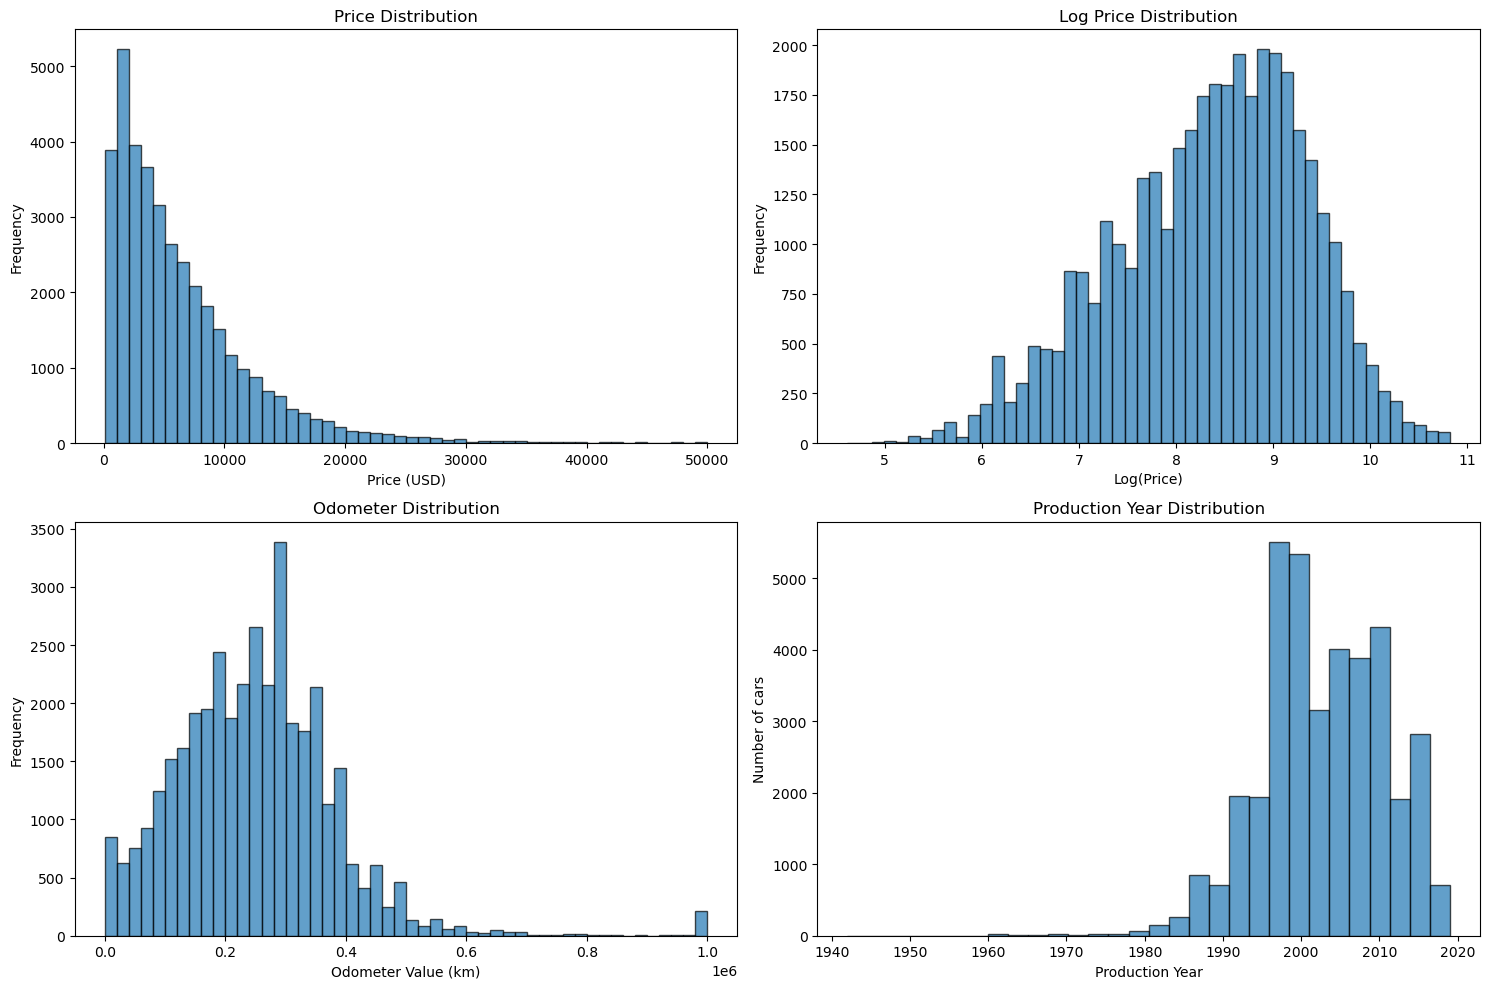

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#Price
axes[0,0].hist(df_clean['price_usd'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price (USD)')
axes[0,0].set_ylabel('Frequency')

#Log pirce
axes[0,1].hist(np.log1p(df_clean['price_usd']), bins=50, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Log Price Distribution')
axes[0,1].set_xlabel('Log(Price)')
axes[0,1].set_ylabel('Frequency')

#Odomoter
axes[1,0].hist(df_clean['odometer_value'], bins=50, edgecolor='black', alpha=0.7)
axes[1,0].set_title('Odometer Distribution')
axes[1,0].set_xlabel('Odometer Value (km)')
axes[1,0].set_ylabel('Frequency')

#Year produced
axes[1,1].hist(df_clean['year_produced'], bins = 30, edgecolor='black', alpha=0.7)
axes[1,1].set_title("Production Year Distribution")
axes[1,1].set_xlabel('Production Year')
axes[1,1].set_ylabel('Number of cars')

plt.tight_layout()
plt.show()

In [12]:
## Filter Cars by Year
def filter_cars_by_year(df, min_year=1990):
    print(f"\n== Filtering by Year (>= {min_year}) ==")
    
    old_cars = df[df['year_produced'] < min_year]
    
    if len(old_cars) > 0:
        print(f"Removing {len(old_cars)} cars manufactured before {min_year}")
        print("  Year distribution of removed cars:")
        for year, count in old_cars['year_produced'].value_counts().sort_index().items():
            print(f"  - {year}: {count} cars")
        
        df_filtered = df[df['year_produced'] >= min_year]
    else:
        print(f"No cars older than {min_year}")
        df_filtered = df
    
    return df_filtered

df_clean = filter_cars_by_year(df_clean, min_year=1990)



== Filtering by Year (>= 1990) ==
Removing 1780 cars manufactured before 1990
  Year distribution of removed cars:
  - 1942: 1 cars
  - 1950: 1 cars
  - 1956: 1 cars
  - 1959: 1 cars
  - 1960: 18 cars
  - 1961: 2 cars
  - 1962: 6 cars
  - 1963: 6 cars
  - 1964: 4 cars
  - 1965: 5 cars
  - 1966: 4 cars
  - 1967: 4 cars
  - 1968: 10 cars
  - 1969: 7 cars
  - 1970: 4 cars
  - 1971: 2 cars
  - 1972: 7 cars
  - 1973: 4 cars
  - 1974: 7 cars
  - 1975: 15 cars
  - 1976: 15 cars
  - 1977: 11 cars
  - 1978: 27 cars
  - 1979: 12 cars
  - 1980: 28 cars
  - 1981: 31 cars
  - 1982: 50 cars
  - 1983: 63 cars
  - 1984: 109 cars
  - 1985: 150 cars
  - 1986: 269 cars
  - 1987: 289 cars
  - 1988: 284 cars
  - 1989: 333 cars


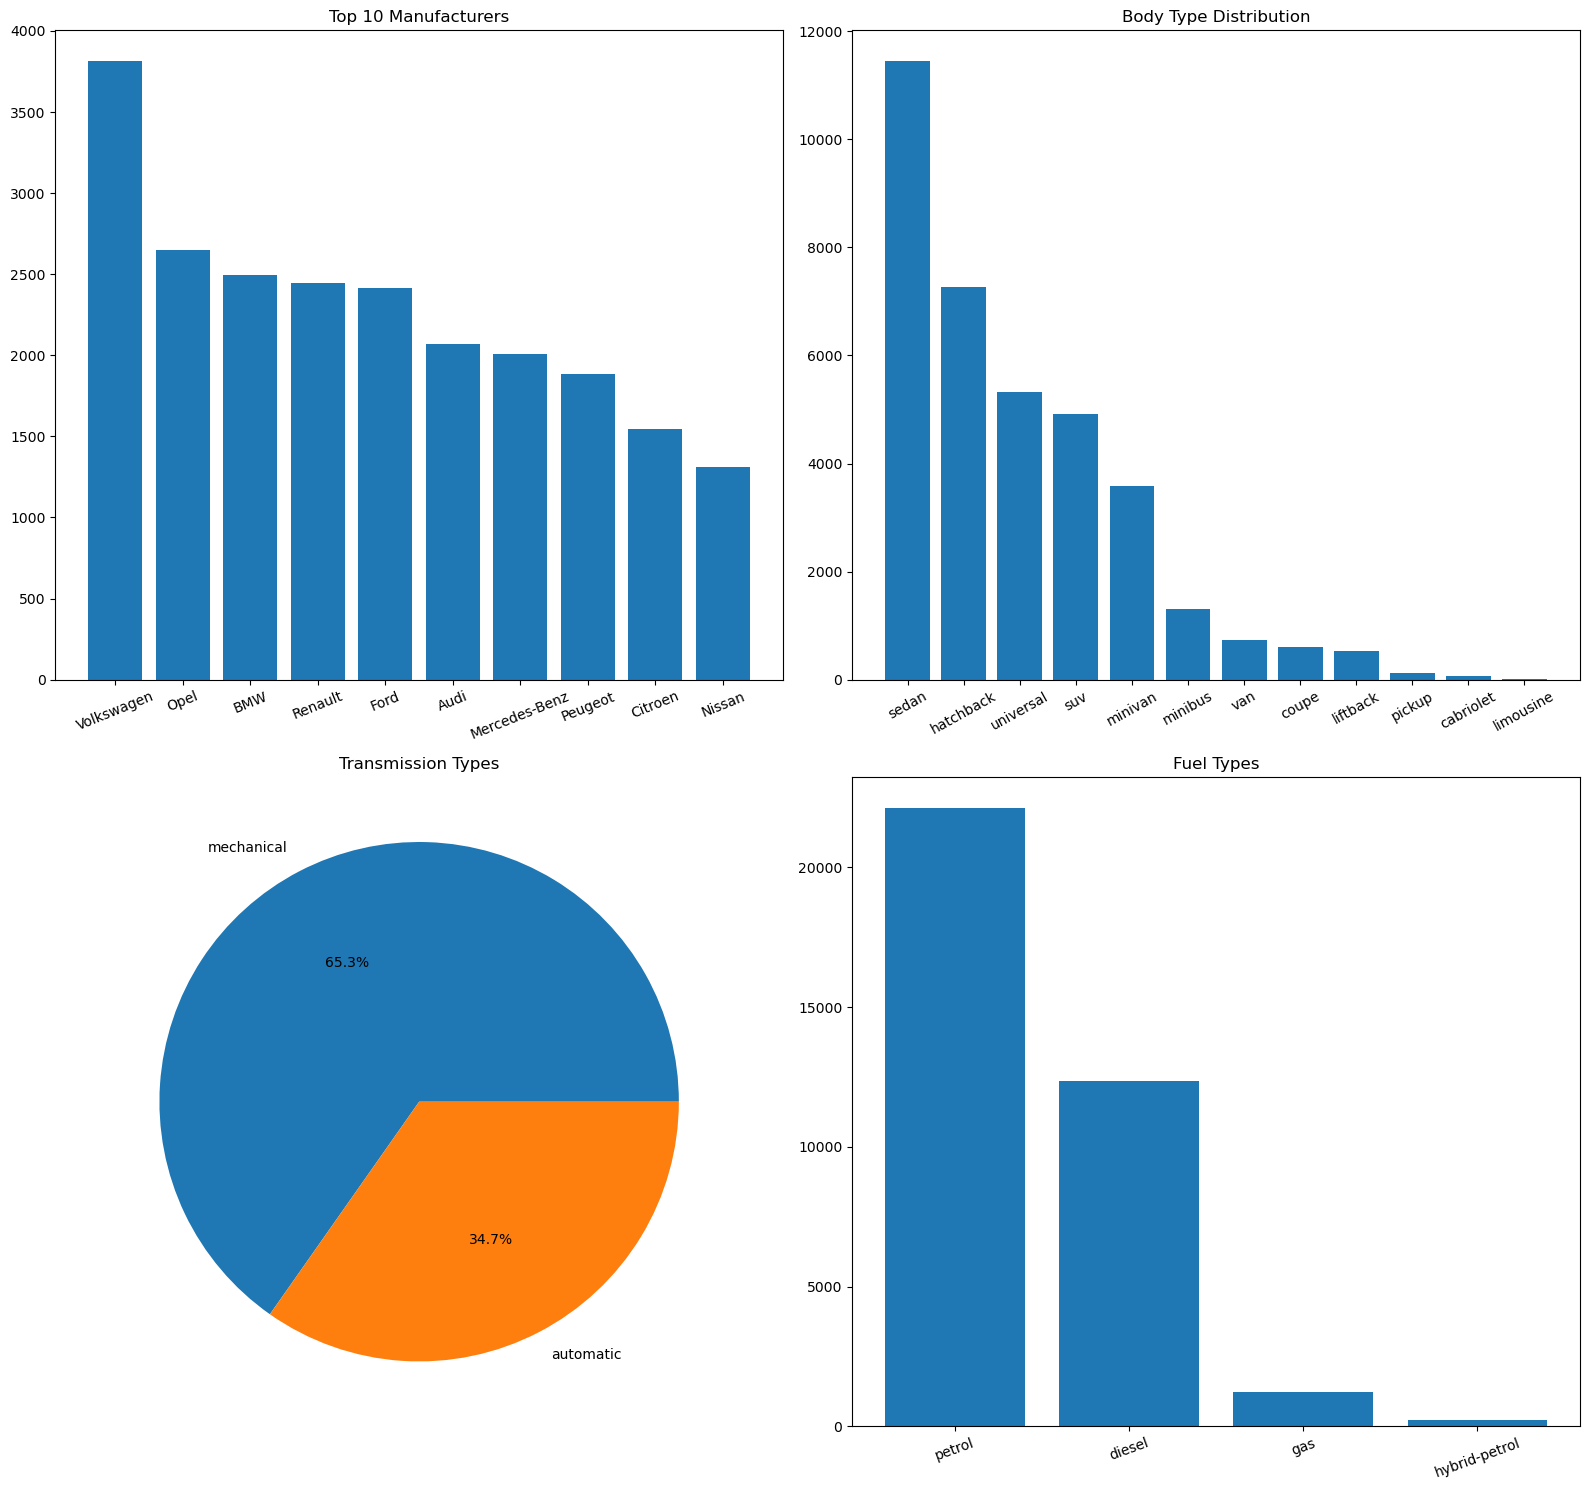

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16,15))

top_manufacturers = df_clean['manufacturer_name'].value_counts().head(10)
axes[0,0].bar(top_manufacturers.index, top_manufacturers.values)
axes[0,0].set_title('Top 10 Manufacturers')
axes[0,0].tick_params(axis='x', rotation=22)

body_types = df_clean['body_type'].value_counts()
axes[0,1].bar(body_types.index, body_types.values)
axes[0,1].set_title('Body Type Distribution')
axes[0,1].tick_params(axis='x', rotation=29)

transmission = df_clean['transmission'].value_counts()
axes[1,0].pie(transmission.values, labels=transmission.index, autopct='%1.1f%%')
axes[1,0].set_title('Transmission Types')

fuel_types = df_clean['engine_fuel'].value_counts()
axes[1,1].bar(fuel_types.index, fuel_types.values)
axes[1,1].set_title('Fuel Types')
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## Brand with expensive used cars

Brands with expensive cars
Total expensive cars: 99
Brands with expensive used cars: 
 Mercedes-Benz: 31 cars
 BMW: 29 cars
 Lexus: 8 cars
 Audi: 7 cars
 Land Rover: 7 cars
 Jaguar: 5 cars
 Toyota: 3 cars
 Volvo: 3 cars
 Porsche: 1 cars
 Ford: 1 cars
 Volkswagen: 1 cars
 Chevrolet: 1 cars
 Honda: 1 cars
 Chrysler: 1 cars


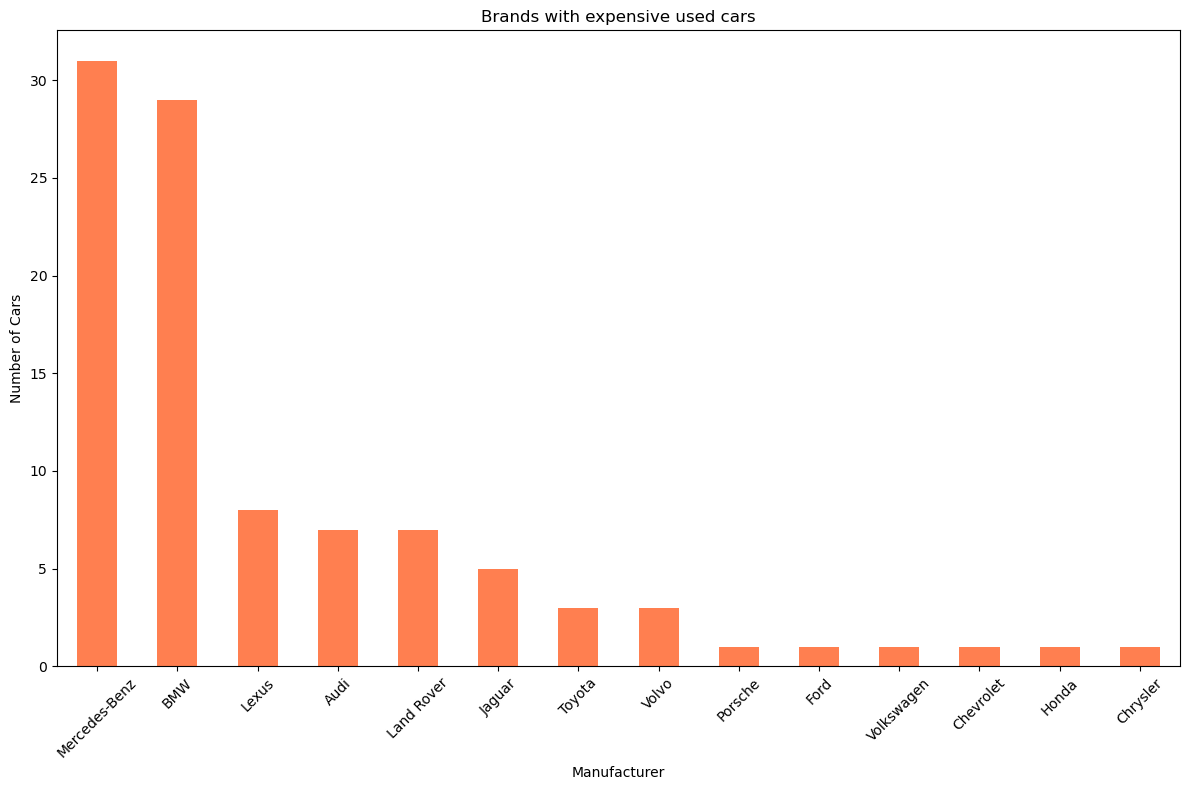

In [14]:
expensive_cars = df_clean[df_clean['price_usd'] > 40000]
expensive_brands = expensive_cars['manufacturer_name'].value_counts()

print("Brands with expensive cars")
print(f"Total expensive cars: {len(expensive_cars)}")
print(f"Brands with expensive used cars: ")
for brand, count in expensive_brands.items():
    print(f" {brand}: {count} cars")

#Plot
plt.figure(figsize=(12,8))
expensive_brands.plot(kind='bar', color='coral')
plt.title('Brands with expensive used cars')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Relationship visualisation

Text(0, 0.5, 'Average Price (USD)')

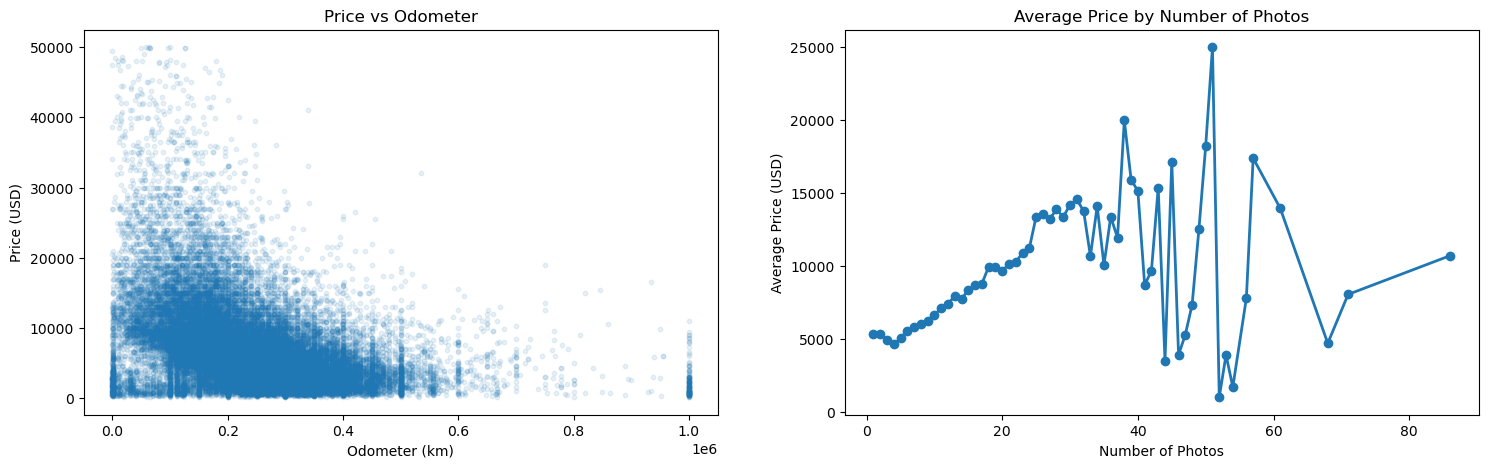

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))

#Price vs Odometer
axes[0].scatter(df_clean['odometer_value'], df_clean['price_usd'], alpha=0.1, s=10)
axes[0].set_title("Price vs Odometer")
axes[0].set_xlabel("Odometer (km)")
axes[0].set_ylabel("Price (USD)")

# axes[1,1].axis('off')
# price_by_year = df_clean.groupby('year_produced')['price_usd'].agg(['mean', 'median', 'count']).reset_index()
# axes[1].plot(price_by_year['year_produced'], price_by_year['mean'], marker='o', linewidth=2, label='Average Price')
# axes[1].plot(price_by_year['year_produced'], price_by_year['median'], marker='x', linewidth=2, label='Median Price')
# axes[1].set_title('Price Trends by Production Year')
# axes[1].set_xlabel('Production year')
# axes[1].set_ylabel('Price (USD)')
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# axes[1].scatter(df_clean['year_produced'], df_clean['price_usd'], alpha=0.3)
# axes[1].set_title("Price vs Odometer")
# axes[1].set_xlabel("Production Year")
# axes[1].set_ylabel("Price (USD)")
# sns.boxplot(data=df_clean, x='engine_capacity_bin', y='price_usd', ax=axes[1])
# axes[1].set_title("Price vs Engine Capacity")
# axes[1].set_xlabel("Engine Capacity (L)")
# axes[1].set_ylabel("Price (USD)")


photos_avg_price = df_clean.groupby('number_of_photos')['price_usd'].mean()
axes[1].plot(photos_avg_price.index, photos_avg_price.values, marker='o', linewidth=2)
axes[1].set_title('Average Price by Number of Photos')
axes[1].set_xlabel('Number of Photos')
axes[1].set_ylabel('Average Price (USD)')

## Avg Price by Engine Capacity

=== Average Price by Engine Capacity ===
engine_capacity_bin
<1.5l        5335.542471
1.5-2.0l     5835.272250
2.0-2.5l     6746.842666
2.5-3.0l    11496.076742
3.0-4.0l    11280.436705
>4.0l       13522.375165
Name: price_usd, dtype: float64


C:\Users\hafiz\AppData\Local\Temp\ipykernel_14980\2643011244.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  engine_avg_price = df_clean.groupby('engine_capacity_bin')['price_usd'].mean()


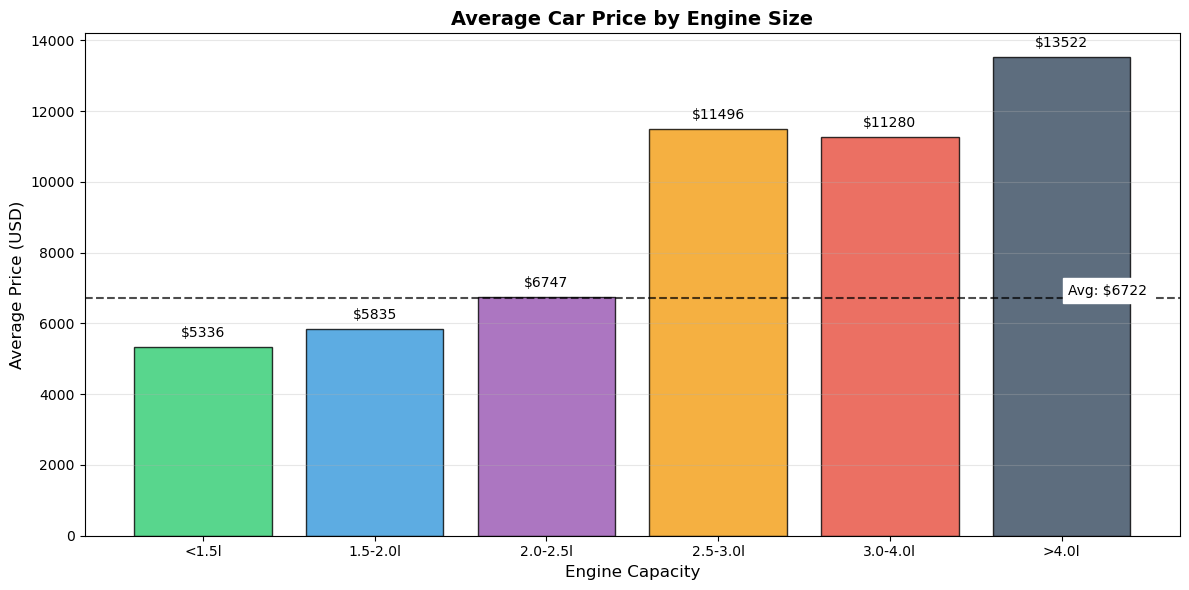


Key Insights:
1. Overall average price: $6722
2. Most expensive engine size: >4.0l ($13522)
3. Cheapest engine size: <1.5l ($5336)


In [16]:
# Price vs Engine Capacity (Simplified)
# Create engine capacity bins
df_clean['engine_capacity_bin'] = pd.cut(df_clean['engine_capacity'],
                                         bins=[0, 1.5, 2.0, 2.5, 3.0, 4.0, 10],
                                         labels=['<1.5l', '1.5-2.0l', '2.0-2.5l', '2.5-3.0l', '3.0-4.0l', '>4.0l'])

# Calculate average price by engine capacity
engine_avg_price = df_clean.groupby('engine_capacity_bin')['price_usd'].mean()

print("=== Average Price by Engine Capacity ===")
print(engine_avg_price)

# Simple bar chart
plt.figure(figsize=(12, 6))
colors = ['#2ecc71', '#3498db', "#9754b2", '#f39c12', '#e74c3c', '#34495e']

bars = plt.bar(engine_avg_price.index, engine_avg_price.values, 
               color=colors, alpha=0.8, edgecolor='black', linewidth=1)

# Add price labels
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height + 200,
                f'${height:.0f}', ha='center', va='bottom', fontsize=10)

plt.title("Average Car Price by Engine Size", fontsize=14, fontweight='bold')
plt.xlabel("Engine Capacity", fontsize=12)
plt.ylabel("Average Price (USD)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

# Add overall average line
overall_avg = df_clean['price_usd'].mean()
plt.axhline(y=overall_avg, color='black', linestyle='--', alpha=0.7, linewidth=1.5)
plt.text(len(engine_avg_price)-0.5, overall_avg, f'Avg: ${overall_avg:.0f}', 
         ha='right', va='bottom', fontsize=10, backgroundcolor='white')

plt.tight_layout()
plt.show()

# Quick insights
print(f"\nKey Insights:")
print(f"1. Overall average price: ${overall_avg:.0f}")
print(f"2. Most expensive engine size: {engine_avg_price.idxmax()} (${engine_avg_price.max():.0f})")
print(f"3. Cheapest engine size: {engine_avg_price.idxmin()} (${engine_avg_price.min():.0f})")

## Number of cars by engine capacity

=== Number of Cars by Engine Capacity ===
engine_capacity_bin
<1.5l        5370
1.5-2.0l    19292
2.0-2.5l     6444
2.5-3.0l     2388
3.0-4.0l     1584
>4.0l         848
Name: count, dtype: int64


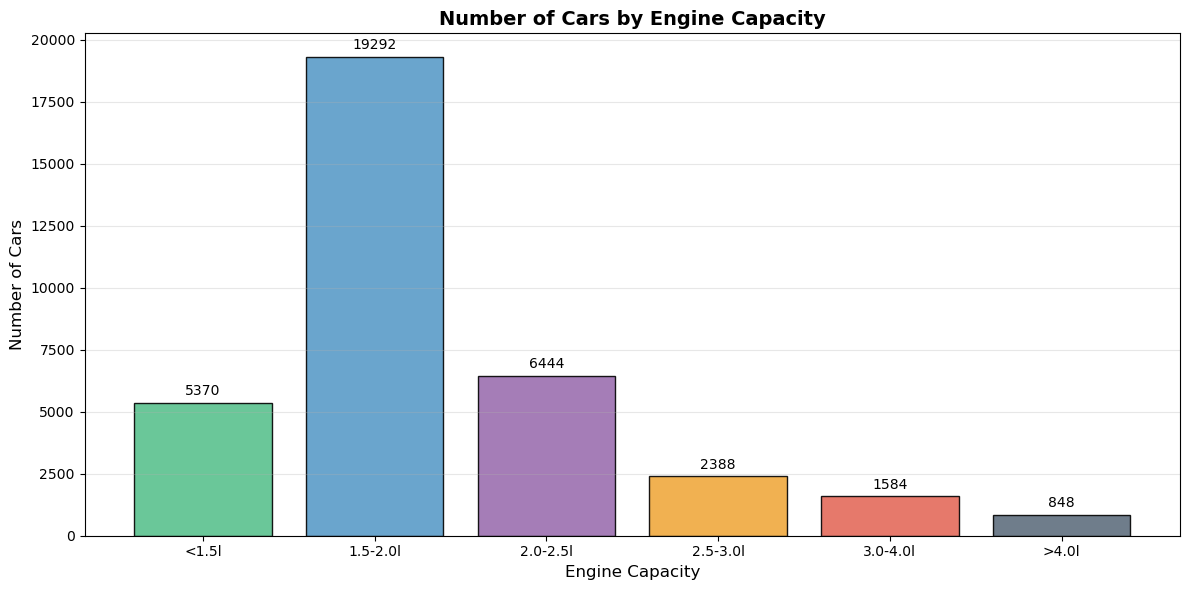


Key Insights:
1. Most common engine size: 1.5-2.0l (19292 cars)
2. Least common engine size: >4.0l (848 cars)
3. Total cars analysed: 35926


In [17]:
df_clean['engine_capacity_bin'] = pd.cut(
    df_clean['engine_capacity'],
    bins=[0, 1.5, 2.0, 2.5, 3.0, 4.0, 10],
    labels=['<1.5l', '1.5-2.0l', '2.0-2.5l', '2.5-3.0l', '3.0-4.0l', '>4.0l']
)

engine_count = df_clean['engine_capacity_bin'].value_counts().sort_index()
print("=== Number of Cars by Engine Capacity ===")
print(engine_count)

plt.figure(figsize=(12, 6))

# Define colors for each engine group (match your image style)
colors = [
    '#5AC18E',  # <1.5L  (green)
    '#5A9BC8',  # 1.5–2.0L (blue)
    '#9B6FB0',  # 2.0–2.5L (purple)
    '#F0A93E',  # 2.5–3.0L (orange)
    '#E46A5B',  # 3.0–4.0L (red)
    '#5F6F7F'   # >4.0L (dark grey)
]

bars = plt.bar(
    engine_count.index,
    engine_count.values,
    color=colors,
    alpha=0.9,
    edgecolor='black',
    linewidth=1
)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (engine_count.max() * 0.01),
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Number of Cars by Engine Capacity", fontsize=14, fontweight='bold')
plt.xlabel("Engine Capacity", fontsize=12)
plt.ylabel("Number of Cars", fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


print("\nKey Insights:")
print(f"1. Most common engine size: {engine_count.idxmax()} ({engine_count.max()} cars)")
print(f"2. Least common engine size: {engine_count.idxmin()} ({engine_count.min()} cars)")
print(f"3. Total cars analysed: {engine_count.sum()}")


## Finding the Volkswagen and Opel cars in the 1.5-2.0l

=== VOLKSWAGEN & OPEL CARS (1.5L-2.0L) ===

Total cars in 1.5L-2.0L range: 20656
Volkswagen & Opel cars in this range: 4451
Market share: 21.5%

Breakdown by Manufacturer:

Volkswagen:
  • Count: 2714 cars
  • Avg price: $6671
  • Avg year: 2003
  • Price range: $300-$38500
  • Top models:
    - Passat: 1155 cars (avg $5436)
    - Golf: 412 cars (avg $3838)
    - Sharan: 165 cars (avg $7187)

Opel:
  • Count: 1737 cars
  • Avg price: $4576
  • Avg year: 2002
  • Price range: $200-$22900
  • Top models:
    - Astra: 547 cars (avg $4051)
    - Vectra: 451 cars (avg $2668)
    - Zafira: 298 cars (avg $6563)


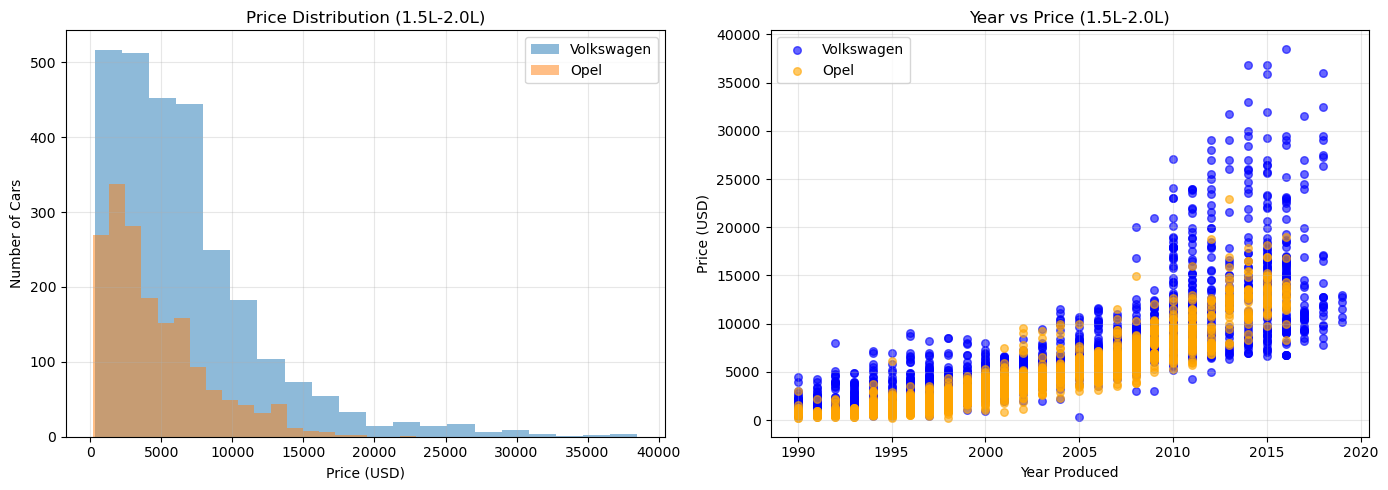


CLUSTERING RECOMMENDATIONS

Based on the analysis, I recommend clustering by:

1. PRICE SEGMENTS:
   • Budget (< $5,000)
   • Mid-range ($5,000 - $10,000)
   • Premium ($10,000+)

2. ENGINE SIZE CATEGORIES:
   • Small (0-1.5L)
   • Medium (1.5-2.0L) ← Volkswagen/Opel focus
   • Large (2.0-3.0L)
   • Extra Large (>3.0L)

3. CAR AGE GROUPS:
   • Vintage (pre-1990)
   • Older (1990-2000)
   • Modern (2000-2010)
   • Recent (2010+)

4. MANUFACTURER TIERS:
   • Economy (Opel, Renault, Ford, etc.)
   • Mid-tier (Volkswagen, Toyota, Honda, etc.)
   • Luxury (BMW, Mercedes, Audi, etc.)

5. BODY TYPE:
   • Sedans
   • Hatchbacks
   • SUVs
   • Minivans/Vans

EXAMPLE: CLUSTER VW/OPEL 1.5L-2.0L CARS

Cluster distribution for Volkswagen & Opel (1.5L-2.0L):

By Price Segment:
  Budget: 2385 cars (53.6%), avg $2606
  Mid-range: 1403 cars (31.5%), avg $7154
  Premium: 663 cars (14.9%), avg $14784

By Age Group:
  Older: 1890 cars (42.5%), avg year 1996
  Modern: 1703 cars (38.3%), avg year 2006
  Re

C:\Users\hafiz\AppData\Local\Temp\ipykernel_14980\1354771506.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vw_opel_cars['price_segment'] = pd.cut(vw_opel_cars['price_usd'],
C:\Users\hafiz\AppData\Local\Temp\ipykernel_14980\1354771506.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vw_opel_cars['age_group'] = pd.cut(vw_opel_cars['year_produced'],
C:\Users\hafiz\AppData\Local\Temp\ipykernel_14980\1354771506.py:131: FutureWarning: The default of observed=False is deprecated and will be changed to

In [18]:
# Analyze Volkswagen and Opel cars in 1.5L-2.0L range
print("=== VOLKSWAGEN & OPEL CARS (1.5L-2.0L) ===")

# Filter for Volkswagen and Opel cars with 1.5L-2.0L engines
target_engines = df_clean[(df_clean['engine_capacity'] >= 1.5) & (df_clean['engine_capacity'] <= 2.0)]
vw_opel_cars = target_engines[target_engines['manufacturer_name'].isin(['Volkswagen', 'Opel'])]

print(f"\nTotal cars in 1.5L-2.0L range: {len(target_engines)}")
print(f"Volkswagen & Opel cars in this range: {len(vw_opel_cars)}")
print(f"Market share: {(len(vw_opel_cars)/len(target_engines)*100):.1f}%\n")

# Breakdown by manufacturer
print("Breakdown by Manufacturer:")
for brand in ['Volkswagen', 'Opel']:
    brand_cars = vw_opel_cars[vw_opel_cars['manufacturer_name'] == brand]
    if len(brand_cars) > 0:
        avg_price = brand_cars['price_usd'].mean()
        avg_year = brand_cars['year_produced'].mean()
        print(f"\n{brand}:")
        print(f"  • Count: {len(brand_cars)} cars")
        print(f"  • Avg price: ${avg_price:.0f}")
        print(f"  • Avg year: {avg_year:.0f}")
        print(f"  • Price range: ${brand_cars['price_usd'].min():.0f}-${brand_cars['price_usd'].max():.0f}")
        
        # Top 3 models
        top_models = brand_cars['model_name'].value_counts().head(3)
        print(f"  • Top models:")
        for model, count in top_models.items():
            model_price = brand_cars[brand_cars['model_name'] == model]['price_usd'].mean()
            print(f"    - {model}: {count} cars (avg ${model_price:.0f})")

# Visualize the comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Price distribution
for brand in ['Volkswagen', 'Opel']:
    brand_prices = vw_opel_cars[vw_opel_cars['manufacturer_name'] == brand]['price_usd']
    if len(brand_prices) > 0:
        ax1.hist(brand_prices, bins=20, alpha=0.5, label=brand)

ax1.set_title("Price Distribution (1.5L-2.0L)")
ax1.set_xlabel("Price (USD)")
ax1.set_ylabel("Number of Cars")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Year vs Price scatter
for brand, color in [('Volkswagen', 'blue'), ('Opel', 'orange')]:
    brand_data = vw_opel_cars[vw_opel_cars['manufacturer_name'] == brand]
    if len(brand_data) > 0:
        ax2.scatter(brand_data['year_produced'], brand_data['price_usd'], 
                   alpha=0.6, label=brand, color=color, s=30)

ax2.set_title("Year vs Price (1.5L-2.0L)")
ax2.set_xlabel("Year Produced")
ax2.set_ylabel("Price (USD)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Clustering recommendations
print("\n" + "="*60)
print("CLUSTERING RECOMMENDATIONS")
print("="*60)

print("\nBased on the analysis, I recommend clustering by:")

print("\n1. PRICE SEGMENTS:")
print("   • Budget (< $5,000)")
print("   • Mid-range ($5,000 - $10,000)")
print("   • Premium ($10,000+)")

print("\n2. ENGINE SIZE CATEGORIES:")
print("   • Small (0-1.5L)")
print("   • Medium (1.5-2.0L) ← Volkswagen/Opel focus")
print("   • Large (2.0-3.0L)")
print("   • Extra Large (>3.0L)")

print("\n3. CAR AGE GROUPS:")
print("   • Vintage (pre-1990)")
print("   • Older (1990-2000)")
print("   • Modern (2000-2010)")
print("   • Recent (2010+)")

print("\n4. MANUFACTURER TIERS:")
print("   • Economy (Opel, Renault, Ford, etc.)")
print("   • Mid-tier (Volkswagen, Toyota, Honda, etc.)")
print("   • Luxury (BMW, Mercedes, Audi, etc.)")

print("\n5. BODY TYPE:")
print("   • Sedans")
print("   • Hatchbacks")
print("   • SUVs")
print("   • Minivans/Vans")

# Create a simple clustering example
print("\n" + "="*60)
print("EXAMPLE: CLUSTER VW/OPEL 1.5L-2.0L CARS")
print("="*60)

# Create clusters based on price and year
vw_opel_cars['price_segment'] = pd.cut(vw_opel_cars['price_usd'],
                                       bins=[0, 5000, 10000, 50000],
                                       labels=['Budget', 'Mid-range', 'Premium'])

vw_opel_cars['age_group'] = pd.cut(vw_opel_cars['year_produced'],
                                   bins=[1900, 1990, 2000, 2010, 2025],
                                   labels=['Vintage', 'Older', 'Modern', 'Recent'])

# Show cluster distribution
print("\nCluster distribution for Volkswagen & Opel (1.5L-2.0L):")

print("\nBy Price Segment:")
price_segments = vw_opel_cars['price_segment'].value_counts()
for segment, count in price_segments.items():
    percentage = (count / len(vw_opel_cars)) * 100
    avg_price = vw_opel_cars[vw_opel_cars['price_segment'] == segment]['price_usd'].mean()
    print(f"  {segment}: {count} cars ({percentage:.1f}%), avg ${avg_price:.0f}")

print("\nBy Age Group:")
age_groups = vw_opel_cars['age_group'].value_counts()
for group, count in age_groups.items():
    percentage = (count / len(vw_opel_cars)) * 100
    avg_year = vw_opel_cars[vw_opel_cars['age_group'] == group]['year_produced'].mean()
    print(f"  {group}: {count} cars ({percentage:.1f}%), avg year {avg_year:.0f}")

# Show example clusters
print("\nExample Clusters (Most Common):")
cluster_combinations = vw_opel_cars.groupby(['price_segment', 'age_group']).size()
for (price_seg, age_group), count in cluster_combinations.nlargest(5).items():
    cluster_data = vw_opel_cars[(vw_opel_cars['price_segment'] == price_seg) & 
                                (vw_opel_cars['age_group'] == age_group)]
    avg_price = cluster_data['price_usd'].mean()
    print(f"  {price_seg} + {age_group}: {count} cars (avg ${avg_price:.0f})")

# Final summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

total_vw_opel_1_5_to_2 = len(vw_opel_cars)
total_all_cars = len(df_clean)
percentage = (total_vw_opel_1_5_to_2 / total_all_cars) * 100

print(f"\n• Volkswagen & Opel (1.5L-2.0L): {total_vw_opel_1_5_to_2} cars")
print(f"• This represents {percentage:.1f}% of all cars in dataset")
print(f"• Most common cluster: {cluster_combinations.idxmax()[0]} {cluster_combinations.idxmax()[1]} cars")
print(f"• Recommendation: Focus on {vw_opel_cars['price_segment'].mode()[0]} segment")

## Brand comparison for Age, Price, Engine capacity

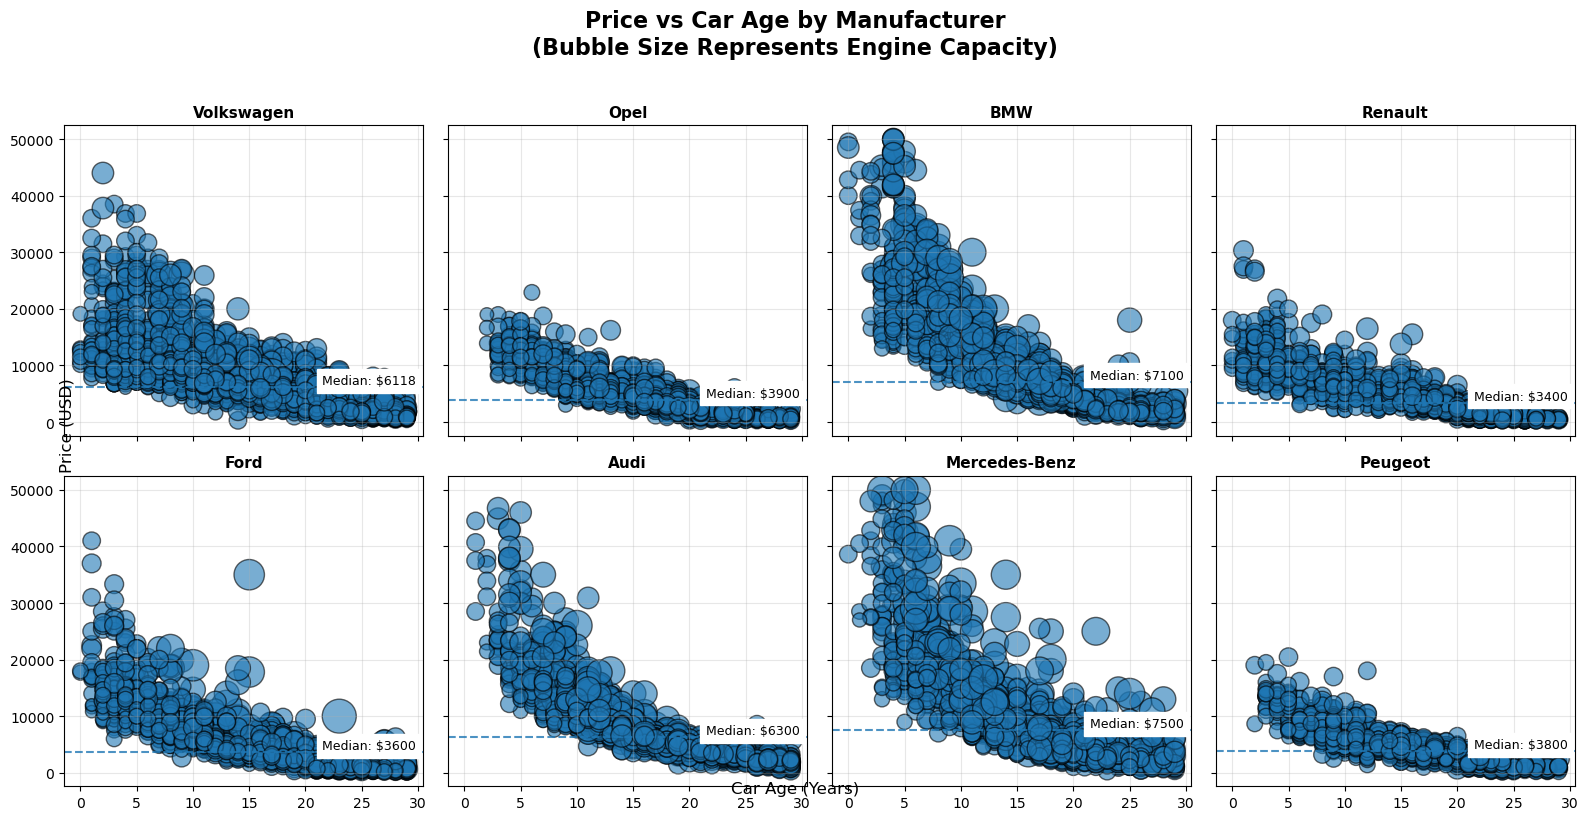

In [19]:
# Brand comparison: Age vs Price vs Engine Capacity
current_year = df_clean['year_produced'].max()
df_clean['car_age'] = current_year - df_clean['year_produced']

TOP_N_BRANDS = 8
top_brands = df_clean['manufacturer_name'].value_counts().head(TOP_N_BRANDS).index

brand_data = df_clean[df_clean['manufacturer_name'].isin(top_brands)]

n_cols = 4
n_rows = (len(top_brands) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, brand in enumerate(top_brands):
    ax = axes[i]
    subset = brand_data[brand_data['manufacturer_name'] == brand]
    
    ax.scatter(
        subset['car_age'],
        subset['price_usd'],
        s=subset['engine_capacity'] * 80,
        alpha=0.6,
        edgecolors='black'
    )
    
    # Median price line
    median_price = subset['price_usd'].median()
    ax.axhline(
        median_price,
        linestyle='--',
        linewidth=1.5,
        alpha=0.8
    )
    
    # Median price annotation
    ax.text(
        0.98,
        median_price,
        f"Median: ${median_price:.0f}",
        transform=ax.get_yaxis_transform(),
        ha='right',
        va='bottom',
        fontsize=9,
        backgroundcolor='white'
    )
    
    ax.set_title(brand, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Price vs Car Age by Manufacturer\n(Bubble Size Represents Engine Capacity)",
    fontsize=16,
    fontweight='bold',
    y=1.02
)

fig.text(0.5, 0.04, "Car Age (Years)", ha='center', fontsize=12)
fig.text(0.04, 0.5, "Price (USD)", va='center', rotation='vertical', fontsize=12)

plt.tight_layout()
plt.show()


C:\Users\hafiz\AppData\Local\Temp\ipykernel_14980\1325037400.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['manufacturer_name', 'engine_capacity_bin'])


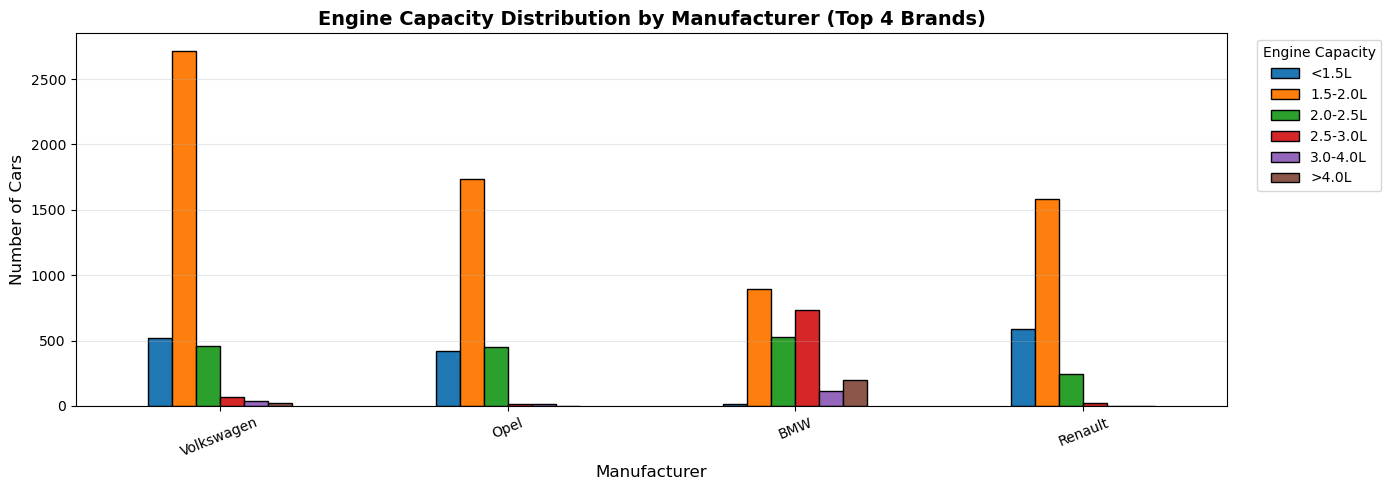

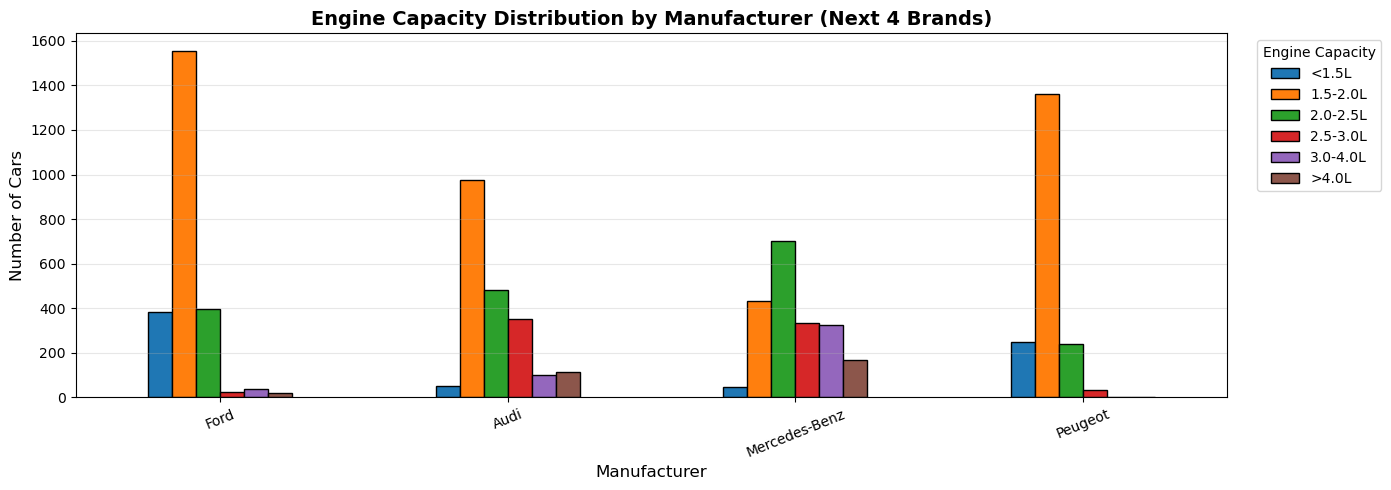

In [20]:
# Top 8 manufacturers by number of cars
top_8_brands = df_clean['manufacturer_name'].value_counts().head(8).index.tolist()

engine_bins = [0, 1.5, 2.0, 2.5, 3.0, 4.0, 10]
engine_labels = ['<1.5L', '1.5-2.0L', '2.0-2.5L', '2.5-3.0L', '3.0-4.0L', '>4.0L']

df_top_brands = df_clean[df_clean['manufacturer_name'].isin(top_8_brands)].copy()

df_top_brands['engine_capacity_bin'] = pd.cut(
    df_top_brands['engine_capacity'],
    bins=engine_bins,
    labels=engine_labels
)

brand_engine_counts = (
    df_top_brands
    .groupby(['manufacturer_name', 'engine_capacity_bin'])
    .size()
    .unstack(fill_value=0)
    .loc[top_8_brands]
)

brands_group_1 = top_8_brands[:4]
brands_group_2 = top_8_brands[4:]

brand_engine_counts.loc[brands_group_1].plot(
    kind='bar',
    stacked=False,
    figsize=(14, 5),
    edgecolor='black'
)

plt.title(
    "Engine Capacity Distribution by Manufacturer (Top 4 Brands)",
    fontsize=14,
    fontweight='bold'
)
plt.xlabel("Manufacturer", fontsize=12)
plt.ylabel("Number of Cars", fontsize=12)
plt.xticks(rotation=22)
plt.legend(title="Engine Capacity", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

brand_engine_counts.loc[brands_group_2].plot(
    kind='bar',
    stacked=False,
    figsize=(14, 5),
    edgecolor='black'
)

plt.title(
    "Engine Capacity Distribution by Manufacturer (Next 4 Brands)",
    fontsize=14,
    fontweight='bold'
)
plt.xlabel("Manufacturer", fontsize=12)
plt.ylabel("Number of Cars", fontsize=12)
plt.xticks(rotation=22)
plt.legend(title="Engine Capacity", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Engine Capacity Distribution by Car Age Group (5-Year Bins)

C:\Users\hafiz\AppData\Local\Temp\ipykernel_14980\1007424386.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['car_age_group', 'engine_capacity_bin'])


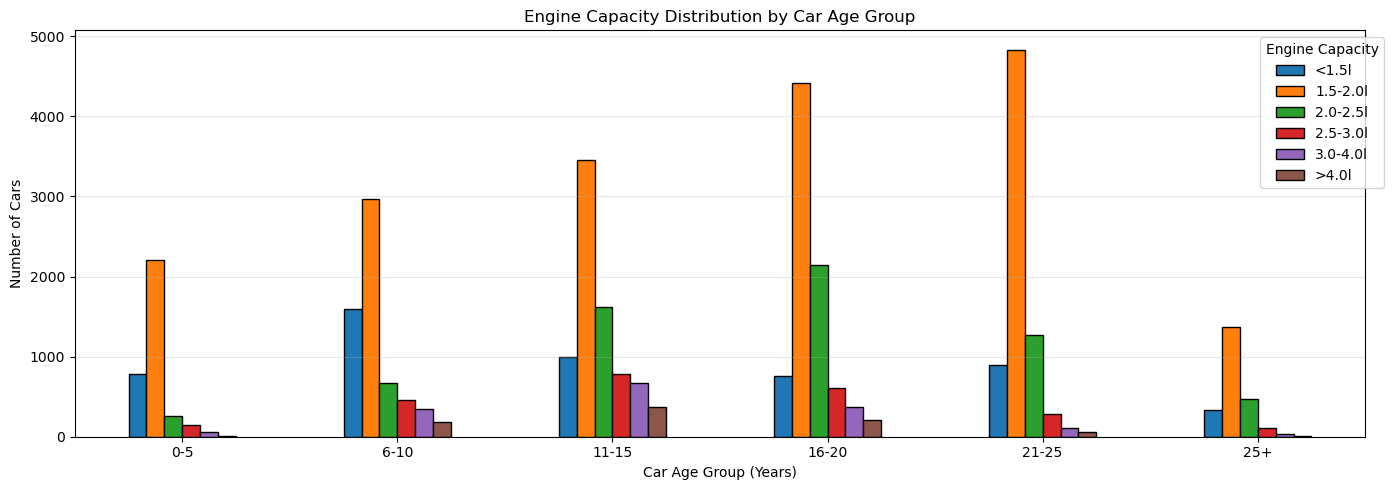

In [21]:
age_bins = [0, 5, 10, 15, 20, 25, 100]
age_labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '25+']

df_clean['car_age_group'] = pd.cut(
    df_clean['car_age'],
    bins=age_bins,
    labels=age_labels,
    right=True
)

age_engine_counts = (
    df_clean
    .groupby(['car_age_group', 'engine_capacity_bin'])
    .size()
    .unstack(fill_value=0)
)

age_engine_counts.plot(
    kind='bar',
    stacked=False,
    figsize=(14,5),
    edgecolor='black'
)

plt.title("Engine Capacity Distribution by Car Age Group")
plt.xlabel("Car Age Group (Years)")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)
plt.legend(title="Engine Capacity", bbox_to_anchor=(1.02, 1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Price vs Year

C:\Users\hafiz\AppData\Local\Temp\ipykernel_14980\1668966123.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('year_bin')['price_usd']


Price Statistics by Production Year
    year_bin     min      max          mean   median  count
0  1940–1970     NaN      NaN           NaN      NaN      0
1  1971–1980     NaN      NaN           NaN      NaN      0
2  1981–1990   110.0  10000.0   1464.402757   1150.0    370
3  1991–1995   100.0  18000.0   1720.056173   1399.0   3899
4  1996–2000   100.0  25000.0   2631.146467   2300.0   9016
5  2001–2005   250.0  35000.0   5244.448115   4794.6   7554
6  2006–2010   400.0  41000.0   8789.017605   7900.0   8334
7  2011–2015  1050.0  50000.0  13832.903239  12000.0   5353
8  2016–2020  4099.0  49900.0  16862.783707  14316.5   1400


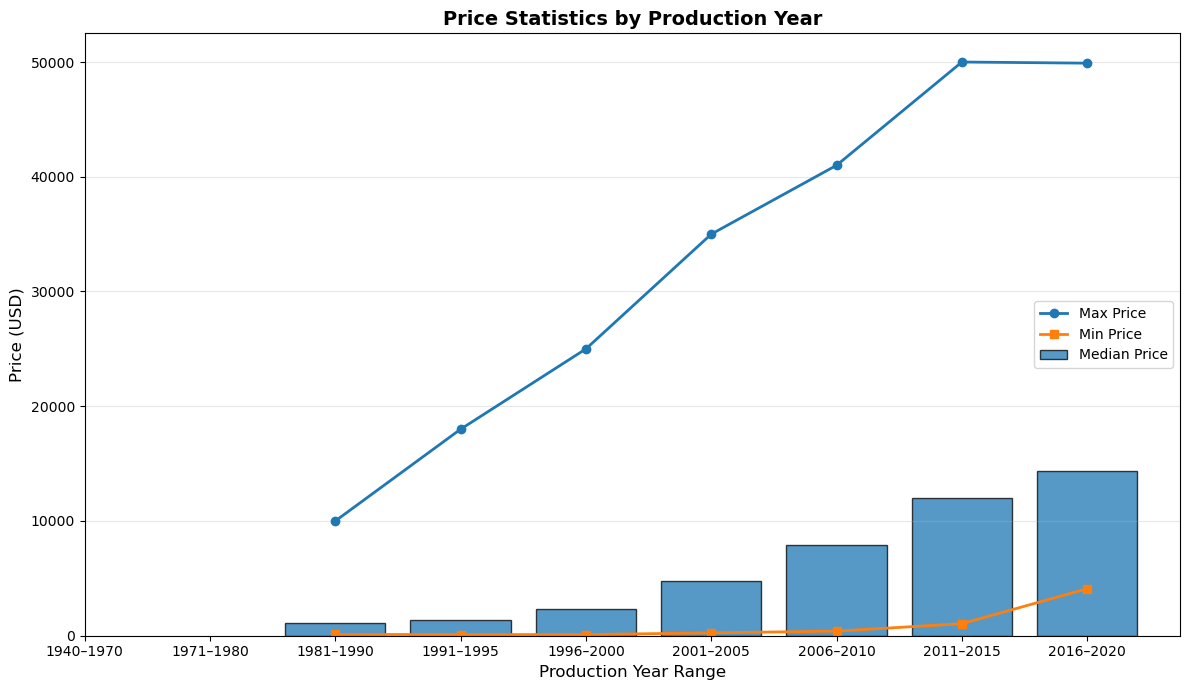

In [22]:
# Price vs Production Year (Binned)

df_clean['year_bin'] = pd.cut(
    df_clean['year_produced'],
    bins=[1940, 1970, 1980, 1990, 1995, 2000, 2005, 2010, 2015, 2020],
    labels=[
        '1940–1970', '1971–1980', '1981–1990', '1991–1995',
        '1996–2000', '2001–2005', '2006–2010', '2011–2015', '2016–2020'
    ]
)

year_stats = (
    df_clean
    .groupby('year_bin')['price_usd']
    .agg(['min', 'max', 'mean', 'median', 'count'])
    .reset_index()
)

print("Price Statistics by Production Year")
print(year_stats)

fig, ax = plt.subplots(figsize=(12, 7))
x_pos = range(len(year_stats))

ax.bar(
    x_pos,
    year_stats['median'],
    alpha=0.75,
    label="Median Price",
    edgecolor='black'
)

# Min & Max lines
ax.plot(x_pos, year_stats['max'], marker='o', label="Max Price", linewidth=2)
ax.plot(x_pos, year_stats['min'], marker='s', label="Min Price", linewidth=2)

ax.set_title("Price Statistics by Production Year", fontsize=14, fontweight='bold')
ax.set_xlabel("Production Year Range", fontsize=12)
ax.set_ylabel("Price (USD)", fontsize=12)

ax.set_xticks(x_pos)
ax.set_xticklabels(year_stats['year_bin'], rotation=0)

ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Price range for all brands


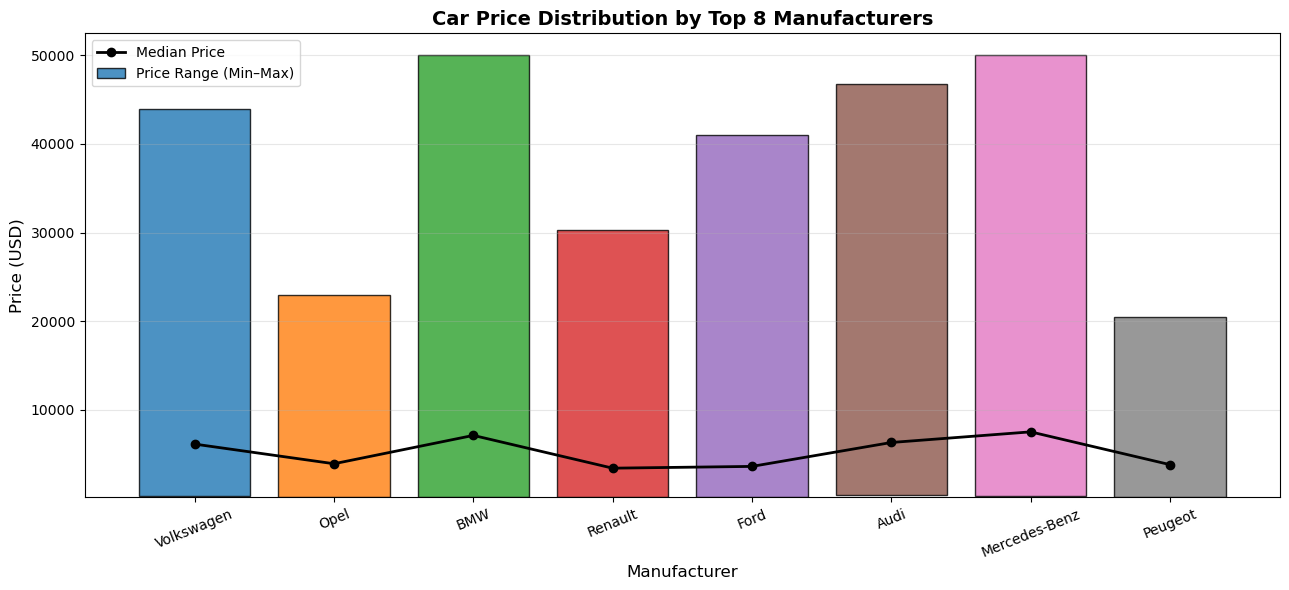

In [23]:
TOP_N_BRANDS = 8

top_manufacturers = df_clean['manufacturer_name'].value_counts().head(TOP_N_BRANDS)
top_brands = top_manufacturers.index.tolist()

brand_price_stats = (
    df_clean[df_clean['manufacturer_name'].isin(top_brands)]
    .groupby('manufacturer_name')['price_usd']
    .agg(
        min_price='min',
        median_price='median',
        max_price='max'
    )
    .loc[top_brands]
)

brands = brand_price_stats.index
x = np.arange(len(brands))

# Distinct colors per brand
colors = plt.cm.tab10.colors[:len(brands)]

plt.figure(figsize=(13, 6))

# Bar: Min–Max range
plt.bar(
    x,
    brand_price_stats['max_price'] - brand_price_stats['min_price'],
    bottom=brand_price_stats['min_price'],
    color=colors,
    edgecolor='black',
    alpha=0.8,
    label='Price Range (Min–Max)'
)

# Median price line
plt.plot(
    x,
    brand_price_stats['median_price'],
    marker='o',
    color='black',
    linewidth=2,
    label='Median Price'
)

plt.xticks(x, brands, rotation=22)
plt.xlabel("Manufacturer", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.title(
    "Car Price Distribution by Top 8 Manufacturers",
    fontsize=14,
    fontweight='bold'
)

plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Heatmap Correlation for Numerical Columns

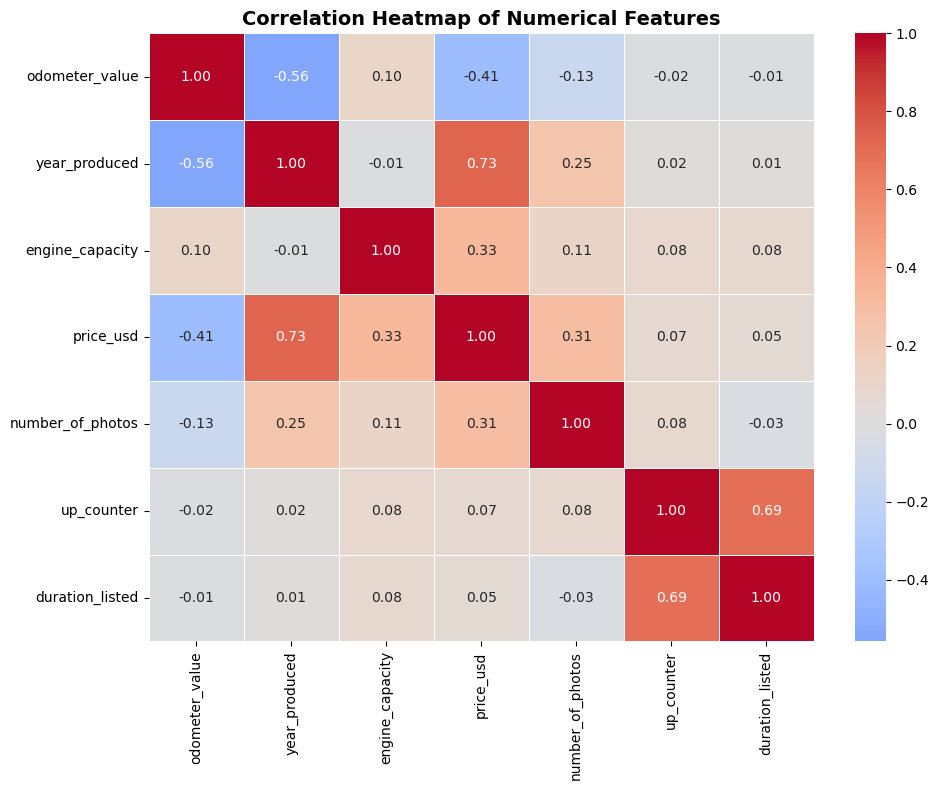

In [24]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean[num_cols].corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Correlation Analysis

=== QUICK CORRELATION ANALYSIS ===

Key Correlations with Price:
  • year_produced: 0.731
  • odometer_value: -0.409
  • engine_capacity: 0.331


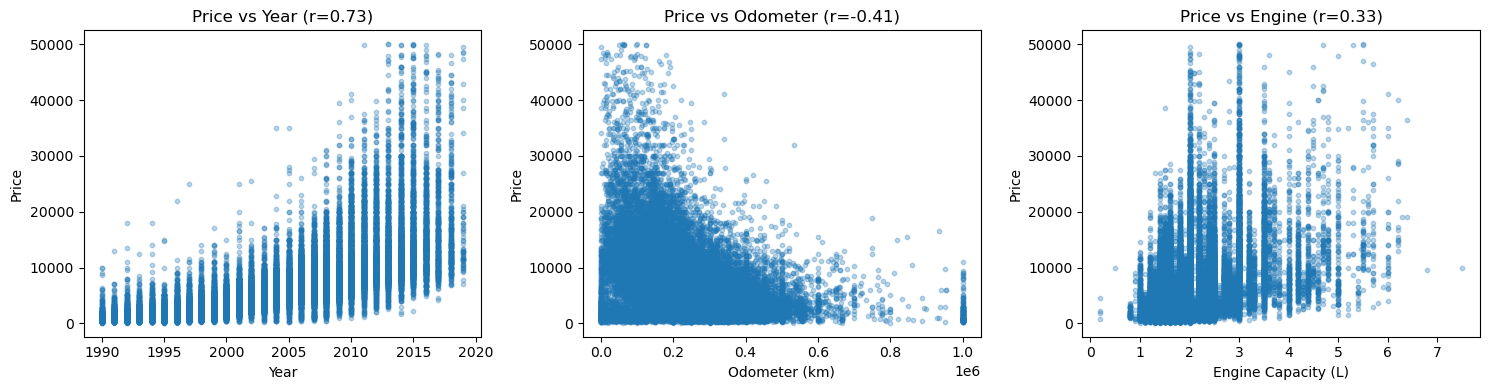

In [25]:
# Correlation Analysis
print("=== QUICK CORRELATION ANALYSIS ===")

# Numerical correlations
numerical_cols = ['price_usd', 'year_produced', 'odometer_value', 'engine_capacity']
corr_matrix = df_clean[numerical_cols].corr()

print("\nKey Correlations with Price:")
for col in ['year_produced', 'odometer_value', 'engine_capacity']:
    corr = corr_matrix.loc['price_usd', col]
    print(f"  • {col}: {corr:.3f}")

# Quick visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Price vs Year
axes[0].scatter(df_clean['year_produced'], df_clean['price_usd'], alpha=0.3, s=10)
axes[0].set_title(f"Price vs Year (r={corr_matrix.loc['price_usd', 'year_produced']:.2f})")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price")

# Price vs Odometer
axes[1].scatter(df_clean['odometer_value'], df_clean['price_usd'], alpha=0.3, s=10)
axes[1].set_title(f"Price vs Odometer (r={corr_matrix.loc['price_usd', 'odometer_value']:.2f})")
axes[1].set_xlabel("Odometer (km)")
axes[1].set_ylabel("Price")

# Price vs Engine
axes[2].scatter(df_clean['engine_capacity'], df_clean['price_usd'], alpha=0.3, s=10)
axes[2].set_title(f"Price vs Engine (r={corr_matrix.loc['price_usd', 'engine_capacity']:.2f})")
axes[2].set_xlabel("Engine Capacity (L)")
axes[2].set_ylabel("Price")

plt.tight_layout()
plt.show()

=== Additional Correlations ===
• Car Age vs Odometer: 0.558
• Engine Capacity vs Odometer: 0.103


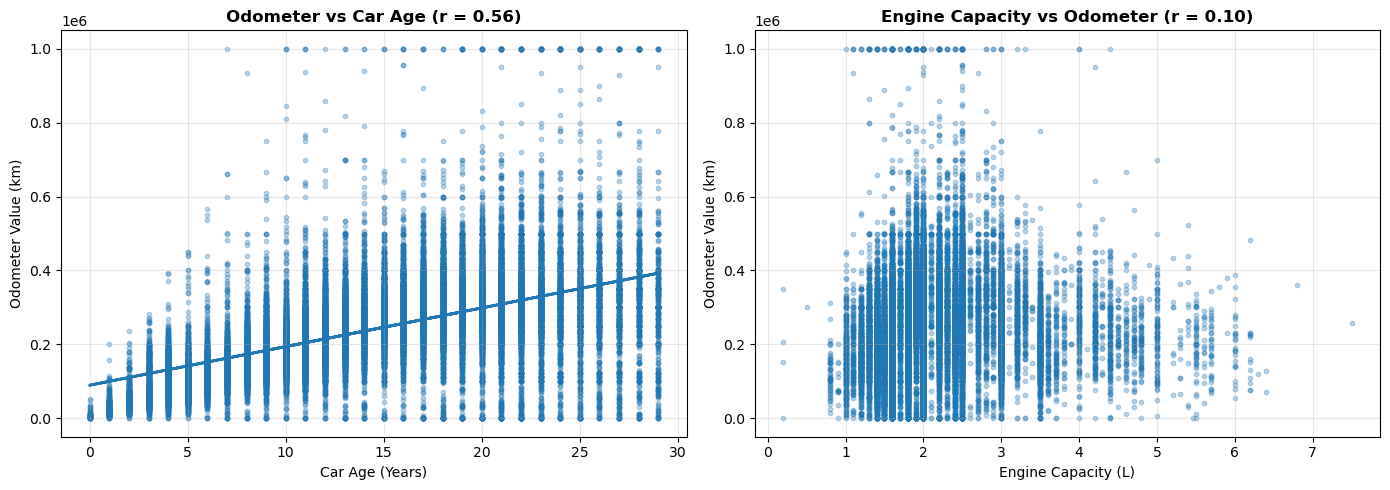

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_age_odometer = df_clean[['car_age', 'odometer_value']].corr().iloc[0, 1]
corr_engine_odometer = df_clean[['engine_capacity', 'odometer_value']].corr().iloc[0, 1]

print("=== Additional Correlations ===")
print(f"• Car Age vs Odometer: {corr_age_odometer:.3f}")
print(f"• Engine Capacity vs Odometer: {corr_engine_odometer:.3f}")

axes[0].scatter(
    df_clean['car_age'],
    df_clean['odometer_value'],
    alpha=0.3,
    s=10
)

# Trend line
z = np.polyfit(df_clean['car_age'], df_clean['odometer_value'], 1)
p = np.poly1d(z)
axes[0].plot(
    df_clean['car_age'],
    p(df_clean['car_age']),
    linewidth=2
)

axes[0].set_title(
    f"Odometer vs Car Age (r = {corr_age_odometer:.2f})",
    fontweight='bold'
)
axes[0].set_xlabel("Car Age (Years)")
axes[0].set_ylabel("Odometer Value (km)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    df_clean['engine_capacity'],
    df_clean['odometer_value'],
    alpha=0.3,
    s=10
)

axes[1].set_title(
    f"Engine Capacity vs Odometer (r = {corr_engine_odometer:.2f})",
    fontweight='bold'
)
axes[1].set_xlabel("Engine Capacity (L)")
axes[1].set_ylabel("Odometer Value (km)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

From the graph above, I could say that the newer the car, the higher the price (Positive correlation). The lower the mileage, the higher the price (Negative correlation). While the engine does not show much of a correlation.

## Feature Engineering

In [27]:
def create_recommendation_features(df):
    "Create features for recommendation system"
    df_enhanced = df.copy()

    print("== Creating Recommendation Features ==")

    current_year = df['year_produced'].max()
    df_enhanced['car_age'] = current_year - df_enhanced['year_produced']

    price_bins = [0, 10000, 20000, 35000, 80000, float('inf')]
    price_labels = ['Budget', 'Economy', 'Mid-Range', 'Premium', 'Luxury']
    df_enhanced['price_category'] = pd.cut(df_enhanced['price_usd'], bins=price_bins, labels=price_labels, right=False)

    df_enhanced['mileage_category'] = pd.cut(df_enhanced['odometer_value'], bins=[0, 50000, 150000, 300000, float('inf')], labels=['Low', 'Medium', 'High', 'Very High'], right=False)

    feature_cols = [f'feature_{i}' for i in range(10)] + ['engine_has_gas', 'has_warranty', 'is_exchangeable']
    df_enhanced['total_features'] = df_enhanced[feature_cols].sum(axis=1)

    df_enhanced['luxury_score'] = (
        df_enhanced['total_features'] +
        (df_enhanced['engine_capacity'] > 2.5).astype(int) +
        df_enhanced['price_category'].map({'Budget': 0, 'Economy': 1, 'Mid-Range': 2, 'Premium': 3, 'Luxury': 4}).astype(int) +
        (df_enhanced['car_age'] < 10).astype(int)
    )

    print("New featurees created: car_age, price_category, mileagee_category, total_features, luxury_score")
    return df_enhanced

df_enhanced = create_recommendation_features(df_clean)

== Creating Recommendation Features ==
New featurees created: car_age, price_category, mileagee_category, total_features, luxury_score


In [28]:
for i in range(10):
    print(f"feature_{i}")
    print(df_enhanced.groupby(f'feature_{i}')['price_usd'].mean())
    print()

feature_0
feature_0
False    7526.701166
True     3432.413502
Name: price_usd, dtype: float64

feature_1
feature_1
False    4456.742308
True     7963.938897
Name: price_usd, dtype: float64

feature_2
feature_2
False     5471.987143
True     10754.786731
Name: price_usd, dtype: float64

feature_3
feature_3
False     4744.825423
True     11495.876507
Name: price_usd, dtype: float64

feature_4
feature_4
False     5417.277508
True     10583.076567
Name: price_usd, dtype: float64

feature_5
feature_5
False     4510.376732
True     10376.488082
Name: price_usd, dtype: float64

feature_6
feature_6
False     5330.408337
True     13001.139761
Name: price_usd, dtype: float64

feature_7
feature_7
False     4685.822420
True     11977.244901
Name: price_usd, dtype: float64

feature_8
feature_8
False     4111.024004
True     10031.852071
Name: price_usd, dtype: float64

feature_9
feature_9
False    4454.258199
True     8215.765565
Name: price_usd, dtype: float64



In [29]:
def validate_cleaned_data(df):
    print("Validate cleanded dataset")
    print("== Data Validation ==")

    print(f"Final dataset shape: {df.shape}")
    print(f"Remaining missing values: {df.isnull().sum()}")

    print("== Detailed Mssing Values ==")
    missing_by_colum = df.isnull().sum()
    missing_by_colum = missing_by_colum[missing_by_colum > 0]

    if len(missing_by_colum) > 0:
        for col, missing_count in missing_by_colum.items():
            print(f"{col}: {missing_count} missing values ({missing_count/len(df)*100:.1f}%)")
    else:
        print("No Missing Values!")

    # Validate num ranges
    print(f"\nPrice range: ${df['price_usd'].min():0f} - ${df['price_usd'].max():.0f}")
    print(f"Odometer Range: {df['odometer_value'].min():0f} KM - {df['odometer_value'].max():.0f} KM")
    print(f"Year Range: {df['year_produced'].min()} - {df['year_produced'].max()}")
    print(f"Car age range: {df['car_age'].min()} - {df['car_age'].max()}")

    # Check new features/column
    print(f"\nPrice categories: {df['price_category'].value_counts().to_dict()}")
    print(f"Mileage categories: {df['mileage_category'].value_counts().to_dict()}")
    print(f"Luxury score range: {df['luxury_score'].min()} - {df['luxury_score'].max()}")

validate_cleaned_data(df_enhanced)

Validate cleanded dataset
== Data Validation ==
Final dataset shape: (35926, 39)
Remaining missing values: manufacturer_name       0
model_name              0
transmission            0
color                   0
odometer_value          0
year_produced           0
engine_fuel             0
engine_has_gas          0
engine_type             0
engine_capacity         0
body_type               0
has_warranty            0
state                   0
drivetrain              0
price_usd               0
is_exchangeable         0
location_region         0
number_of_photos        0
up_counter              0
feature_0               0
feature_1               0
feature_2               0
feature_3               0
feature_4               0
feature_5               0
feature_6               0
feature_7               0
feature_8               0
feature_9               0
duration_listed         0
is_electric             0
engine_capacity_bin     0
car_age                 0
car_age_group          59
year_bin 

### Cleaned data

In [30]:
df_enhanced.to_csv('../data/processed/cleaned_cars.csv', index=False)
print("Cleaned data saved to '../data/processed/cleaned_cars.csv'")

print("\n=== Final Dataset Preview ===")
print(df_enhanced[['manufacturer_name', 'model_name', 'price_usd', 'car_age', 'price_category', 'luxury_score']].tail(10))

Cleaned data saved to '../data/processed/cleaned_cars.csv'

=== Final Dataset Preview ===
      manufacturer_name     model_name  price_usd  car_age price_category  \
38521          Chrysler           Neon     550.00       24         Budget   
38522          Chrysler     PT Cruiser    4000.00       15         Budget   
38523          Chrysler  Grand Voyager    4220.81       20         Budget   
38524          Chrysler            300    3000.00       18         Budget   
38525          Chrysler        Voyager    3300.00       20         Budget   
38526          Chrysler            300    2750.00       19         Budget   
38527          Chrysler     PT Cruiser    4800.00       15         Budget   
38528          Chrysler            300    4300.00       19         Budget   
38529          Chrysler     PT Cruiser    4000.00       18         Budget   
38530          Chrysler        Voyager    3200.00       19         Budget   

       luxury_score  
38521             3  
38522             

## Model Building and Training

### Brand only model prediction test

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df_enhanced[['manufacturer_name']]
y = df_enhanced['price_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('brand', OneHotEncoder(handle_unknown='ignore'), ['manufacturer_name'])
    ]
)

brand_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', LinearRegression())
    ]
)
brand_model.fit(X_train, y_train)

y_pred = brand_model.predict(X_test)
mae_brand = mean_absolute_error(y_test, y_pred)
r2Score_brand = r2_score(y_test, y_pred)

print(f"Brand-only model MAE: ${mae_brand:.0f}")
print(f"Brand + Age model R2: {r2Score_brand:.3f}")

Brand-only model MAE: $3981
Brand + Age model R2: 0.175


### Brand + Car Age

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df_enhanced[['manufacturer_name', 'car_age']]
y = df_enhanced['price_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('brand', OneHotEncoder(handle_unknown='ignore'), ['manufacturer_name']),
        ('age', 'passthrough', ['car_age'])
    ]
)

brand_age_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', LinearRegression())
    ]
)

brand_age_model.fit(X_train, y_train)
y_pred = brand_age_model.predict(X_test)
mae_brand_age = mean_absolute_error(y_test, y_pred)
r2Score = r2_score(y_test, y_pred)

print(f"Brand + Age model MAE: ${mae_brand_age:.0f}")
print(f"Brand + Age model R2: {r2Score:.3f}")

Brand + Age model MAE: $2380
Brand + Age model R2: 0.644


### MAE Comparison

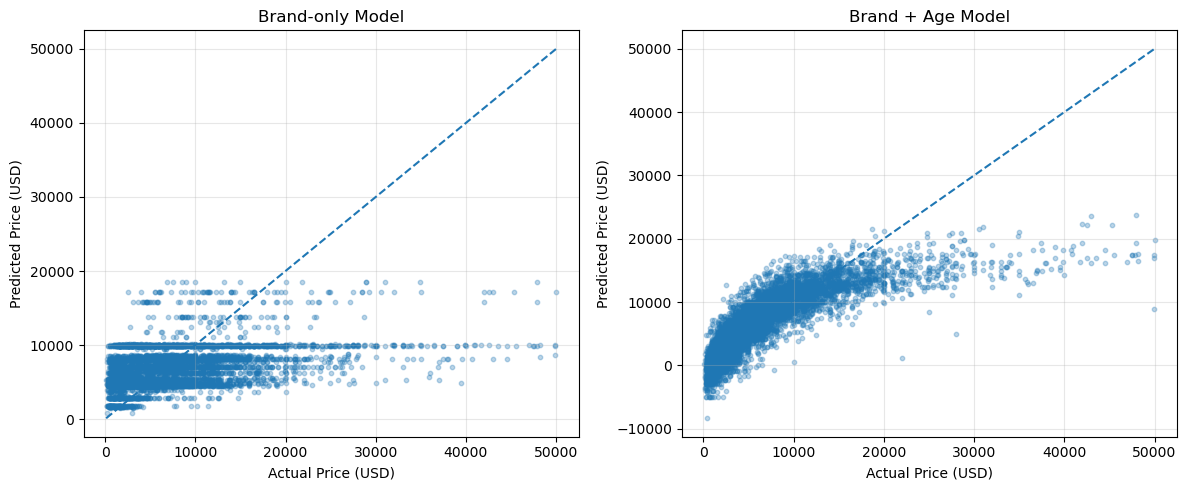

In [33]:
y_pred_brand = brand_model.predict(X_test[['manufacturer_name']])
y_pred_brand_age = brand_age_model.predict(X_test[['manufacturer_name', 'car_age']])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Brand-only
axes[0].scatter(y_test, y_pred_brand, alpha=0.3, s=10)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
axes[0].set_title("Brand-only Model")
axes[0].set_xlabel("Actual Price (USD)")
axes[0].set_ylabel("Predicted Price (USD)")
axes[0].grid(True, alpha=0.3)

# Brand + Age
axes[1].scatter(y_test, y_pred_brand_age, alpha=0.3, s=10)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
axes[1].set_title("Brand + Age Model")
axes[1].set_xlabel("Actual Price (USD)")
axes[1].set_ylabel("Predicted Price (USD)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Compare brands predicted value

In [34]:
X_all = df_enhanced[['manufacturer_name', 'car_age']]
y_all = df_enhanced['price_usd']

df_pred = df_enhanced.copy()
df_pred['predicted_price'] = brand_age_model.predict(X_all)
df_pred['abs_error'] = (df_pred['predicted_price'] - y_all).abs()

brand_mae = (
    df_pred[df_pred['manufacturer_name'].isin(top_brands)]
    .groupby('manufacturer_name')['abs_error']
    .mean()
    .sort_values()
)

brand_mae

manufacturer_name
Opel             1465.783343
Renault          1655.849856
Peugeot          1665.788350
Ford             1983.260210
Audi             2251.403576
Volkswagen       2514.430274
BMW              3405.597652
Mercedes-Benz    3744.521544
Name: abs_error, dtype: float64

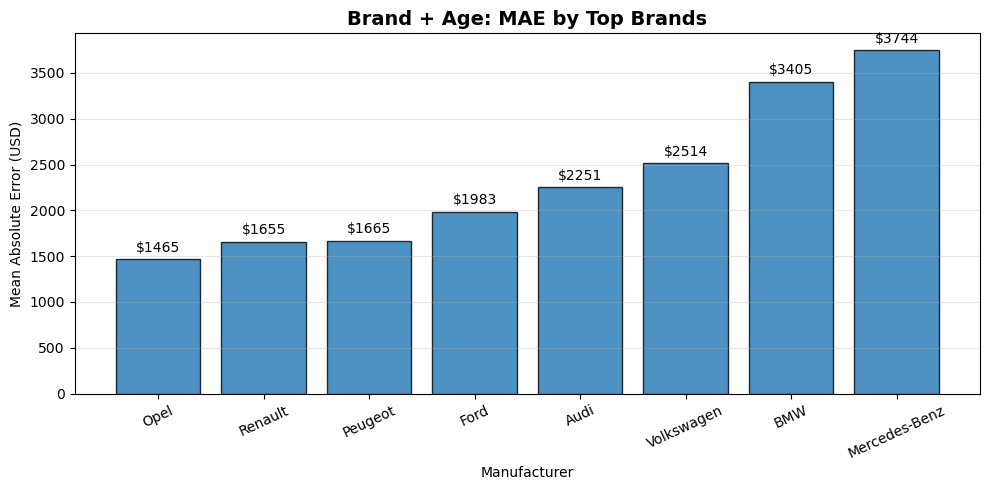

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    brand_mae.index,
    brand_mae.values,
    edgecolor='black',
    alpha=0.8
)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f"${int(height)}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Brand + Age: MAE by Top Brands", fontsize=14, fontweight='bold')
plt.ylabel("Mean Absolute Error (USD)")
plt.xlabel("Manufacturer")
plt.xticks(rotation=25)
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [36]:
df_top8 = df_pred[df_pred['manufacturer_name'].isin(top_brands)]
brand_mae_sorted = (
    df_pred[df_pred['manufacturer_name'].isin(top_brands)]
    .groupby('manufacturer_name')['abs_error']
    .mean()
    .sort_values()
)

# Best & worst accuracy
selected_brands = list(brand_mae_sorted.head(2).index) + \
                  list(brand_mae_sorted.tail(2).index)


print("Selected brands:", selected_brands)


Selected brands: ['Opel', 'Renault', 'BMW', 'Mercedes-Benz']


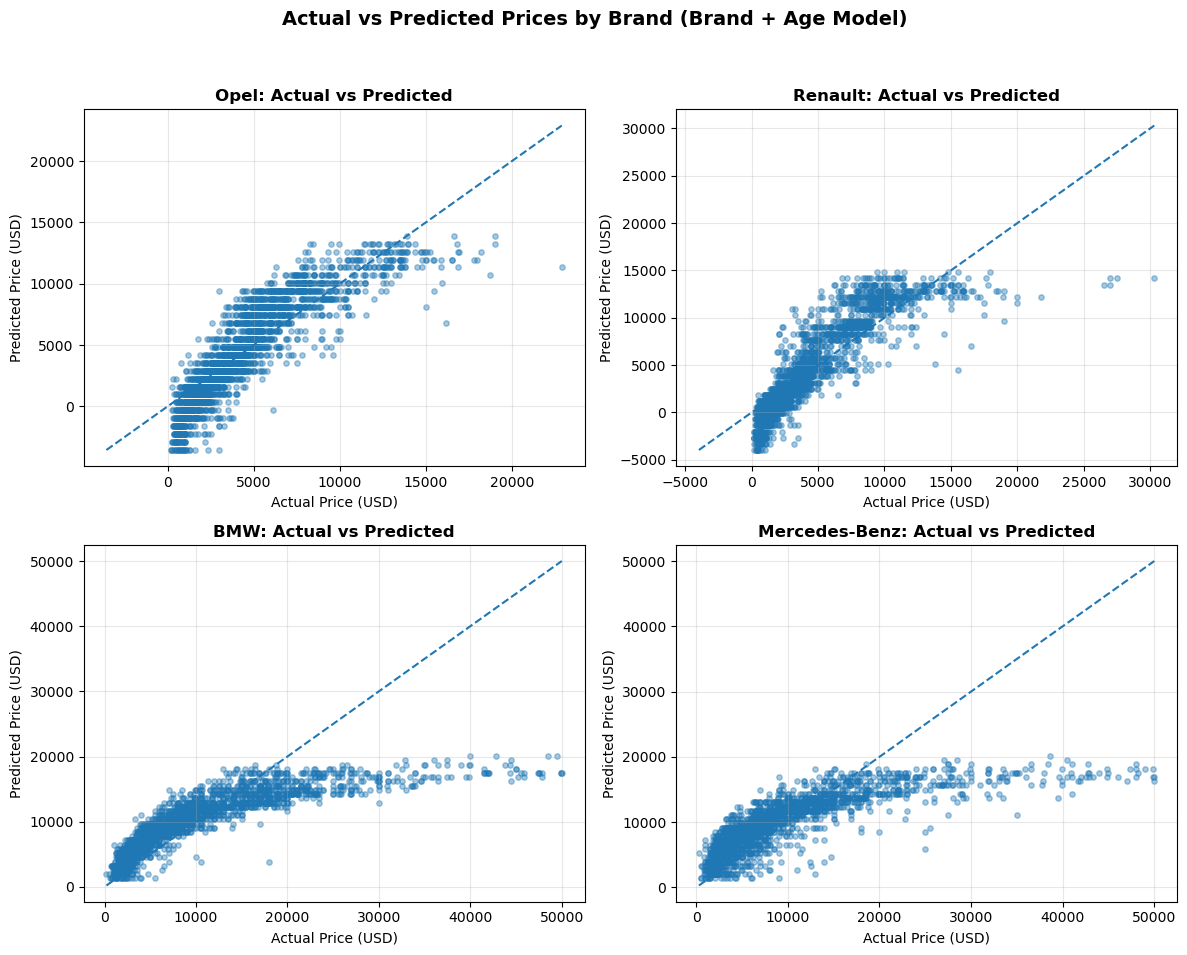

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, brand in zip(axes, selected_brands):
    brand_data = df_top8[df_top8['manufacturer_name'] == brand]

    ax.scatter(
        brand_data['price_usd'],
        brand_data['predicted_price'],
        alpha=0.4,
        s=15
    )

    # Perfect prediction line
    min_val = min(
        brand_data['price_usd'].min(),
        brand_data['predicted_price'].min()
    )
    max_val = max(
        brand_data['price_usd'].max(),
        brand_data['predicted_price'].max()
    )

    ax.plot([min_val, max_val], [min_val, max_val], linestyle='--')

    ax.set_title(f"{brand}: Actual vs Predicted", fontweight='bold')
    ax.set_xlabel("Actual Price (USD)")
    ax.set_ylabel("Predicted Price (USD)")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Actual vs Predicted Prices by Brand (Brand + Age Model)",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Grouping Car Model

In [38]:
model_counts = df_enhanced['model_name'].value_counts()

rare_models = model_counts[model_counts < 30].index

df_enhanced['model_name_grouped'] = df_enhanced['model_name'].replace(
    rare_models,
    'OTHER'
)

print(df_enhanced['model_name_grouped'])

0         Outback
1         Outback
2        Forester
3         Impreza
4          Legacy
           ...   
38526         300
38527       OTHER
38528         300
38529       OTHER
38530     Voyager
Name: model_name_grouped, Length: 35926, dtype: object


### Random Forest Model


In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    'manufacturer_name',
    'model_name_grouped',
    'car_age',
    'engine_capacity',
    'odometer_value',
    'total_features',
    'luxury_score'
]

X = df_enhanced[features]
y = np.log1p(df_enhanced['price_usd'])

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('brand_model', OneHotEncoder(handle_unknown='ignore'), ['manufacturer_name', 'model_name_grouped']),
        ('num', 'passthrough', [
            'car_age',
            'engine_capacity',
            'odometer_value',
            'total_features',
            'luxury_score'
        ])
    ]
)

rf_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', RandomForestRegressor(
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# train
rf_model.fit(X_train, y_train)

# predict n evaluate
y_test_actual = np.expm1(y_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_actual = np.expm1(y_pred_rf)

mae_rf = mean_absolute_error(y_test_actual, y_pred_rf_actual)
r2_rf = r2_score(y_test_actual, y_pred_rf_actual)

print(f"Random Forest MAE: ${mae_rf:.0f}")
print(f"Random Forest R2: {r2_rf:.3f}")

Random Forest MAE: $1022
Random Forest R2: 0.927


In [40]:
ohe = rf_model.named_steps['preprocess'].named_transformers_['brand_model']
brand_features = ohe.get_feature_names_out(['manufacturer_name', 'model_name_grouped'])

numeric_features = [
    'car_age',
    'engine_capacity',
    'odometer_value',
    'total_features',
    'luxury_score'
]

all_features = list(brand_features) + numeric_features

importances = rf_model.named_steps['model'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print(feature_importance_df.head(10))

                             feature  importance
315                          car_age    0.674494
319                     luxury_score    0.101533
316                  engine_capacity    0.085715
317                   odometer_value    0.028519
48      manufacturer_name_Volkswagen    0.010179
318                   total_features    0.010040
2             manufacturer_name_Audi    0.007533
50             manufacturer_name_ВАЗ    0.005923
3              manufacturer_name_BMW    0.005435
31   manufacturer_name_Mercedes-Benz    0.004391


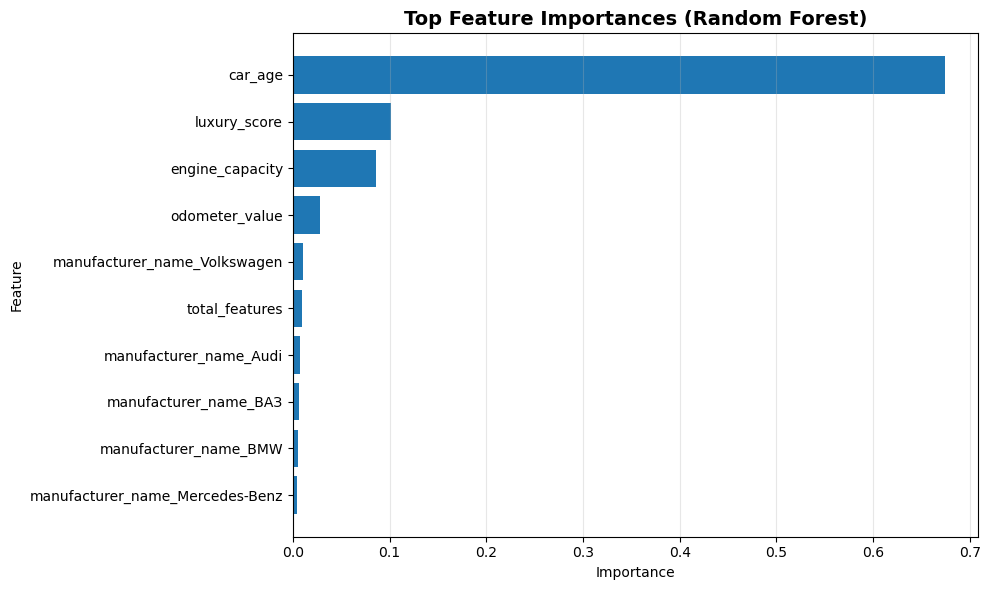

In [41]:
# Plot feature importance
plt.figure(figsize=(10, 6))

top_n = 10
top_features = feature_importance_df.head(top_n)

plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()

plt.title('Top Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Gradient Boosting model

In [42]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

# train
gb_model.fit(X_train, y_train)

#predict
y_test_actual = np.expm1(y_test)
y_pred_gb = gb_model.predict(X_test)
y_pred_gb_actual = np.expm1(y_pred_gb)

#evalute
mae_gb = mean_absolute_error(y_test_actual, y_pred_gb_actual)
r2_gb = r2_score(y_test_actual, y_pred_gb_actual)

print(f"Gradient Boosting MAE: ${mae_gb:.0f}")
print(f"Gradient Boosting R2: {r2_gb:.3f}")

Gradient Boosting MAE: $1386
Gradient Boosting R2: 0.855


### XGBoost Model/

In [43]:
from xgboost import XGBRegressor
xgb_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1,
            random_state=42,
            n_jobs=-1,
            tree_method='hist'
        ))
    ]
)

#train
xgb_model.fit(X_train, y_train)

y_test_actual = np.expm1(y_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb_actual = np.expm1(y_pred_xgb)

mae_xgb = mean_absolute_error(y_test_actual, y_pred_xgb_actual)
r2_xgb = r2_score(y_test_actual, y_pred_xgb_actual)
        
print(f"XGBoost MAE: ${mae_xgb:.0f}")
print(f"XGBoost R2: {r2_xgb:.3f}")

XGBoost MAE: $1065
XGBoost R2: 0.920


### Build Model

In [44]:
from sklearn.ensemble import VotingRegressor

voting_model = VotingRegressor(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model),
        ('xgb', xgb_model)
    ],
    n_jobs=-1
)

#train
voting_model.fit(X_train, y_train)

#predict
y_test_actual = np.expm1(y_test)
y_pred_vote = voting_model.predict(X_test)
y_pred_vote_actual = np.expm1(y_pred_vote)

mae_vote = mean_absolute_error(y_test_actual, y_pred_vote_actual)
r2_vote = r2_score(y_test_actual, y_pred_vote_actual)

print(f"Voting Ensemble MAE: ${mae_vote:.0f}")
print(f"Voting Ensemble R2: {r2_vote:.3f}")

Voting Ensemble MAE: $1099
Voting Ensemble R2: 0.911


### Saving best model

In [45]:
import joblib

joblib.dump(xgb_model, "best_car_price_model.pkl")

['best_car_price_model.pkl']

## DNN Model

In [46]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
X_train_processed = X_train_processed.toarray()
X_test_processed = X_test_processed.toarray()

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

input_dim = X_train_scaled.shape[1]

ann_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(1)
])

# compile model
ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae']
)

# Eearly stopping added
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# train
history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=120,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# predict
y_pred_ann = ann_model.predict(X_test_scaled).flatten()

mae_ann = mean_absolute_error(y_test, y_pred_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print(f"ANN MAE: ${mae_ann:.0f}")
print(f"ANN R2: {r2_ann:.3f}")

Epoch 1/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.5899 - mae: 7.5899 - val_loss: 6.2526 - val_mae: 6.2526
Epoch 2/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8297 - mae: 3.8297 - val_loss: 0.9536 - val_mae: 0.9536
Epoch 3/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5814 - mae: 1.5814 - val_loss: 0.7043 - val_mae: 0.7043
Epoch 4/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2645 - mae: 1.2645 - val_loss: 0.5168 - val_mae: 0.5168
Epoch 5/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1074 - mae: 1.1074 - val_loss: 0.4357 - val_mae: 0.4357
Epoch 6/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9824 - mae: 0.9824 - val_loss: 0.3903 - val_mae: 0.3903
Epoch 7/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8944 - mae: 0.8944 - val_loss: 0.3662 - val_mae: 0.3662
Epoch 8/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8130 - mae: 0.8130 - val_loss: 0.3283 - val_mae: 0.3283
Epoch 9/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.757

## Model Comparison

In [47]:
results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'Voting Ensemble',
        'ANN'
    ],
    'MAE': [
        mae_rf,
        mae_gb,
        mae_xgb,
        mae_vote,
        mae_ann
    ],
    'R2': [
        r2_rf,
        r2_gb,
        r2_xgb,
        r2_vote,
        r2_ann
    ]
}).sort_values(by='R2', ascending=False)

print(results)

               Model          MAE        R2
0      Random Forest  1022.067144  0.926852
2            XGBoost  1065.344966  0.919940
3    Voting Ensemble  1099.346398  0.911234
4                ANN     0.215109  0.895846
1  Gradient Boosting  1385.522633  0.854581


In [48]:
y_pred_real = np.expm1(y_pred_xgb)
y_test_real = np.expm1(y_test)

## Actual vs Predicted Prices (XGBoost)

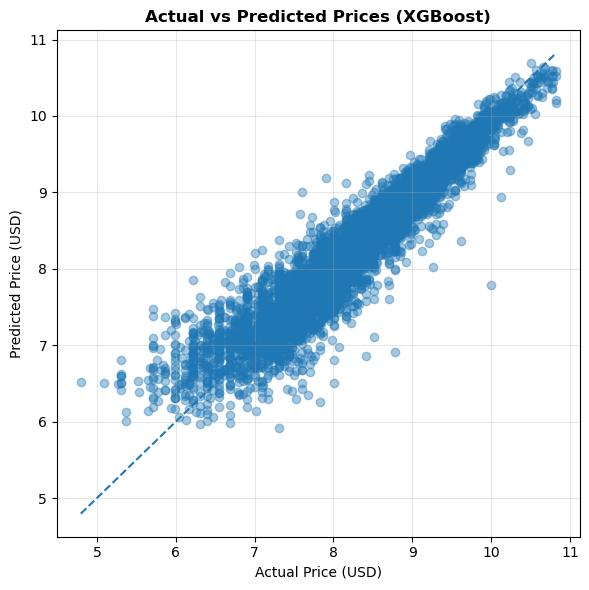

In [49]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.title('Actual vs Predicted Prices (XGBoost)', fontweight='bold')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

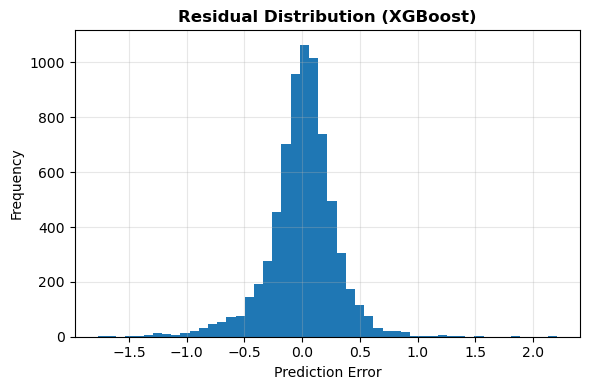

In [50]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.title('Residual Distribution (XGBoost)', fontweight='bold')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

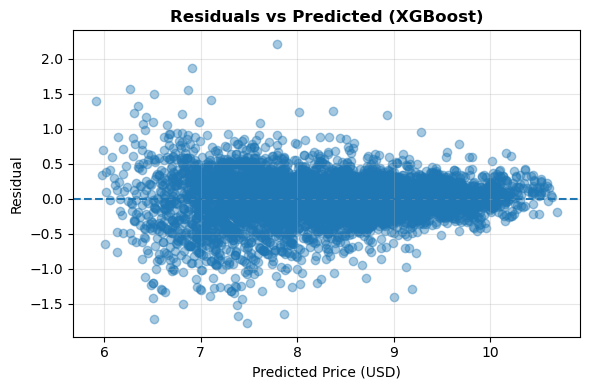

In [51]:
plt.figure(figsize=(6,4))

plt.scatter(y_pred_xgb, residuals, alpha=0.4)
plt.axhline(0, linestyle='--')

plt.title('Residuals vs Predicted (XGBoost)', fontweight='bold')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residual')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

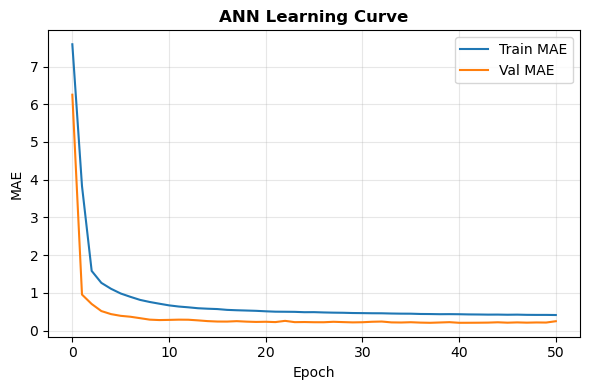

In [52]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train MAE')
plt.plot(history.history['val_loss'], label='Val MAE')
plt.legend()
plt.title('ANN Learning Curve', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
# saving best model
import joblib
joblib.dump(xgb_model, "best_car_price_model.pkl")

['best_car_price_model.pkl']

## Prediction function

In [54]:
def predict_car_price(model, input_df):
    pred_log = model.predict(input_df)
    pred_real = np.expm1(pred_log)
    return pred_real

In [55]:
sample = X_test.iloc[[0]].copy()

pred_price = predict_car_price(xgb_model, sample)

print("Predicted price:", pred_price[0])
print("Actual price:", y_test_real.iloc[0])

Predicted price: 5524.865
Actual price: 6400.000000000005


## Overall Real MAE (no log)

In [56]:
mae_real = mean_absolute_error(y_test_real, y_pred_real)
r2_real = r2_score(y_test_real, y_pred_real)

print(f"Final Real MAE: ${mae_real:.0f}")
print(f"Final Real R2: {r2_real:.3f}")

Final Real MAE: $1065
Final Real R2: 0.920


### Price Tier MAE

In [57]:
p80 = y_test_real.quantile(0.8)
p40 = y_test_real.quantile(0.4)

low_mask = y_test_real < p40
mid_mask = (y_test_real >= p40) & (y_test_real < p80)
high_mask = y_test_real >= p80

print("Low-tier MAE:", mean_absolute_error(y_test_real[low_mask], y_pred_real[low_mask]))
print("Mid-tier MAE:", mean_absolute_error(y_test_real[mid_mask], y_pred_real[mid_mask]))
print("High-tier MAE:", mean_absolute_error(y_test_real[high_mask], y_pred_real[high_mask]))

Low-tier MAE: 550.9721987364546
Mid-tier MAE: 944.0434140844243
High-tier MAE: 2311.595724551772


In [58]:
feature_importance_df[
    feature_importance_df['feature'].str.contains('model_name_grouped')
].head(10)

,feature,importance
221,model_name_grouped_OTHER,0.003508
229,model_name_grouped_Passat,0.001789
277,model_name_grouped_T4,0.001379
271,model_name_grouped_Sprinter,0.001333
223,model_name_grouped_Omega,0.001220
182,model_name_grouped_Galaxy,0.001138
306,model_name_grouped_Xantia,0.001133
217,model_name_grouped_Mondeo,0.000733
168,model_name_grouped_Escort,0.000659
200,model_name_grouped_Land Cruiser,0.000592


In [59]:
test1 = pd.DataFrame([{
    "manufacturer_name": "BMW",
    "model_name_grouped": "530",
    "car_age": 5,
    "engine_capacity": 2.0,
    "odometer_value": 80000,
    "total_features": 5,
    "luxury_score": 2
}])

test2 = test1.copy()
test2["model_name_grouped"] = "525"

print(np.expm1(rf_model.predict(test1)))
print(np.expm1(rf_model.predict(test2)))

[12046.88900962]
[12046.88900962]


In [64]:
model = "320"

df_model = df_enhanced[df_enhanced['model_name'] == model]

print(df_model[['manufacturer_name', 'model_name', 'year_produced', 'price_usd']])

      manufacturer_name model_name  year_produced  price_usd
19327             Lifan        320           2012     3700.0
27501               BMW        320           2019    39999.0
27524               BMW        320           2018    32900.0
27544               BMW        320           2012    15000.0
27551               BMW        320           2013    15300.0
...                 ...        ...            ...        ...
30087               BMW        320           2005     7000.0
30090               BMW        320           2004     7200.0
30097               BMW        320           2013    17500.0
30098               BMW        320           2014    19800.0
30104               BMW        320           1991     3000.0

[228 rows x 4 columns]
